<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/claude%2Faffectionate-allen-8eoaxi/604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smartline Analysis Handbook
Part I (sections 1–8): the full-panel pipeline with cleaned data of every home's meter files, cluster 24-hour load shapes, link clusters to survey variables, build the gas-subset heat-pump scenario and the bedroom damp-cold indicators.

Part II (sections 9–15): reproduces the models and figures of the project's report from the raw sensor files for the matched pair UPRN 111 (gas) vs UPRN 15 (ASHP).

# 1. Import

In [1]:
from __future__ import annotations

import json
import math
import re
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Mount Drive and set paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = Path(r'/content/drive/MyDrive/01_Smartline')
OUT = Path(r'/content/drive/MyDrive/Colab')
FIG = OUT / "figures"

SURVEY = ROOT / "SurveyAndUprns" / "uprns.csv"
ELECTRICITY_DIR = ROOT / "SensorData" / "Electricity"
GAS_DIR = ROOT / "SensorData" / "Gas"
BEDROOM_DIR = ROOT / "SensorData" / "RelativeHumidityAndTemperature" / "Bedroom"

RANDOM_STATE = 42
GAS_M3_TO_KWH = 11.2
HEAT_PUMP_COP = 2.8

Mounted at /content/drive


# 3. Result container and helpers

In [3]:
@dataclass
class EnergyResult:
    household_features: pd.DataFrame
    daily: pd.DataFrame
    profile: pd.DataFrame
    file_audit: pd.DataFrame


def ensure_dirs() -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    FIG.mkdir(parents=True, exist_ok=True)


def parse_uprn(path: Path) -> int | None:
    match = re.search(r"ts_(\d+)_sid", path.name)
    return int(match.group(1)) if match else None


def first_matching_column(columns: list[str], needle: str) -> str:
    matches = [c for c in columns if needle.lower() in c.lower()]
    if not matches:
        raise ValueError(f"No column containing {needle!r}; columns={columns}")
    return matches[0]


def robust_upper_bound(series: pd.Series, absolute_cap: float | None = None) -> float:
    clean = series.dropna()
    if clean.empty:
        return np.nan
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 3 * iqr if iqr > 0 else clean.quantile(0.99)
    if absolute_cap is not None:
        upper = min(float(upper), absolute_cap)
    return float(max(upper, clean.quantile(0.95)))

# 4. Reading and cleaning meter files

In [4]:
def read_energy_file(path: Path) -> pd.DataFrame:
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    value_col = first_matching_column(columns, "diffValue")
    df = pd.read_csv(path, usecols=["datetime", value_col])
    df = df.rename(columns={value_col: "value"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    return df


def process_energy_folder(folder: Path, label: str, daily_cap: float | None) -> EnergyResult:
    feature_rows: list[dict] = []
    daily_rows: list[pd.DataFrame] = []
    profile_rows: list[dict] = []
    audit_rows: list[dict] = []
    files = sorted(folder.glob("ts_*.csv"))

    for i, path in enumerate(files, 1):
        if i % 25 == 0 or i == 1 or i == len(files):
            print(f"[{label}] {i}/{len(files)} files: {path.name}", flush=True)
        uprn = parse_uprn(path)
        if uprn is None:
            continue
        try:
            raw = read_energy_file(path)
        except Exception as exc:
            audit_rows.append({"UPRN": uprn, "file": path.name, "status": f"read_error: {exc}"})
            continue

        values = raw.set_index("datetime")["value"]
        hourly = values.resample("h").sum(min_count=1).rename("hourly_value").to_frame()
        hourly["negative_hour"] = hourly["hourly_value"] < 0
        hourly.loc[hourly["negative_hour"], "hourly_value"] = np.nan
        hourly["date"] = hourly.index.date
        hourly["hour"] = hourly.index.hour

        daily = (
            hourly.groupby("date")
            .agg(
                daily_value=("hourly_value", "sum"),
                active_hours=("hourly_value", "count"),
                negative_hours=("negative_hour", "sum"),
            )
            .reset_index()
        )
        daily["UPRN"] = uprn
        daily["date"] = pd.to_datetime(daily["date"])
        daily["weekday"] = daily["date"].dt.dayofweek
        daily["month"] = daily["date"].dt.month
        daily["is_weekend"] = daily["weekday"].isin([5, 6])

        upper = robust_upper_bound(daily.loc[daily["active_hours"] >= 12, "daily_value"], daily_cap)
        daily["valid_day"] = (
            (daily["active_hours"] >= 12)
            & (daily["daily_value"] > 0)
            & (daily["daily_value"] <= upper)
        )
        valid_daily = daily[daily["valid_day"]].copy()
        daily_rows.append(daily)

        valid_dates = set(valid_daily["date"].dt.date)
        valid_date_mask = pd.Series(hourly.index.date, index=hourly.index).isin(valid_dates)
        valid_hourly = hourly[valid_date_mask].copy()
        valid_hourly["date"] = pd.to_datetime(valid_hourly["date"])
        daily_totals = valid_daily.set_index("date")["daily_value"]
        valid_hourly["daily_total"] = valid_hourly["date"].map(daily_totals)
        valid_hourly["share"] = valid_hourly["hourly_value"].fillna(0) / valid_hourly["daily_total"]
        profile = valid_hourly.groupby("hour")["share"].mean()

        valid_days = len(valid_daily)
        if valid_days >= 30:
            for hour in range(24):
                profile_rows.append(
                    {
                        "UPRN": uprn,
                        "hour": hour,
                        "mean_share": float(profile.get(hour, 0.0)),
                    }
                )

            mean_by_hour = valid_hourly.groupby("hour")["hourly_value"].mean()
            feature_rows.append(
                {
                    "UPRN": uprn,
                    f"{label}_valid_days": valid_days,
                    f"{label}_mean_daily": valid_daily["daily_value"].mean(),
                    f"{label}_median_daily": valid_daily["daily_value"].median(),
                    f"{label}_p90_daily": valid_daily["daily_value"].quantile(0.90),
                    f"{label}_winter_mean_daily": valid_daily.loc[
                        valid_daily["month"].isin([12, 1, 2]), "daily_value"
                    ].mean(),
                    f"{label}_summer_mean_daily": valid_daily.loc[
                        valid_daily["month"].isin([6, 7, 8]), "daily_value"
                    ].mean(),
                    f"{label}_weekend_mean_daily": valid_daily.loc[
                        valid_daily["is_weekend"], "daily_value"
                    ].mean(),
                    f"{label}_weekday_mean_daily": valid_daily.loc[
                        ~valid_daily["is_weekend"], "daily_value"
                    ].mean(),
                    f"{label}_morning_share": profile.reindex(range(6, 10), fill_value=0).sum(),
                    f"{label}_daytime_share": profile.reindex(range(10, 16), fill_value=0).sum(),
                    f"{label}_evening_share": profile.reindex(range(16, 23), fill_value=0).sum(),
                    f"{label}_overnight_share": profile.reindex(list(range(0, 6)) + [23], fill_value=0).sum(),
                    f"{label}_peak_hour": int(mean_by_hour.idxmax()) if not mean_by_hour.empty else np.nan,
                }
            )

        audit_rows.append(
            {
                "UPRN": uprn,
                "file": path.name,
                "status": "ok",
                "raw_rows": len(raw),
                "first_datetime": raw["datetime"].min(),
                "last_datetime": raw["datetime"].max(),
                "daily_upper_bound": upper,
                "valid_days": valid_days,
                "removed_negative_hours": int(hourly["negative_hour"].sum()),
            }
        )

    household_features = pd.DataFrame(feature_rows)
    daily_all = pd.concat(daily_rows, ignore_index=True) if daily_rows else pd.DataFrame()
    profile_all = pd.DataFrame(profile_rows)
    audit = pd.DataFrame(audit_rows)
    return EnergyResult(household_features, daily_all, profile_all, audit)

# 5. Load-shape clustering and survey links

In [5]:
def cluster_electricity_profiles(profile: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    wide = profile.pivot(index="UPRN", columns="hour", values="mean_share").fillna(0)
    wide = wide.reindex(columns=range(24), fill_value=0)
    wide = wide.div(wide.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    silhouette_rows = []
    for k in range(2, 6):
        if len(wide) <= k:
            continue
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
        labels = model.fit_predict(wide)
        silhouette_rows.append({"k": k, "silhouette": silhouette_score(wide, labels)})
    silhouette = pd.DataFrame(silhouette_rows)

    # A three-cluster solution has a marginally higher silhouette in this data,
    # but it isolates a single household. Two clusters are more defensible for
    # reporting because both groups have enough homes for aggregate comparison.
    chosen_k = 2
    model = KMeans(n_clusters=chosen_k, n_init=100, random_state=RANDOM_STATE)
    labels = model.fit_predict(wide)
    assignments = pd.DataFrame({"UPRN": wide.index, "cluster_id": labels})

    centers = pd.DataFrame(model.cluster_centers_, columns=range(24))
    centers["cluster_id"] = range(chosen_k)
    centers["peak_hour"] = centers[range(24)].idxmax(axis=1)
    centers["evening_share"] = centers[list(range(16, 23))].sum(axis=1)
    centers["daytime_share"] = centers[list(range(10, 16))].sum(axis=1)
    centers["overnight_share"] = centers[list(range(0, 6)) + [23]].sum(axis=1)

    labels_by_cluster: dict[int, str] = {}
    remaining = set(centers["cluster_id"].tolist())
    evening_cluster = int(centers.sort_values("evening_share", ascending=False).iloc[0]["cluster_id"])
    labels_by_cluster[evening_cluster] = "Evening-peaking"
    remaining.remove(evening_cluster)
    baseload_cluster = int(
        centers[centers["cluster_id"].isin(remaining)]
        .sort_values("overnight_share", ascending=False)
        .iloc[0]["cluster_id"]
    )
    labels_by_cluster[baseload_cluster] = "Flat or overnight-weighted"
    remaining.remove(baseload_cluster)
    for cluster_id in remaining:
        labels_by_cluster[int(cluster_id)] = "Daytime-weighted"

    assignments["load_shape_cluster"] = assignments["cluster_id"].map(labels_by_cluster)
    centers["load_shape_cluster"] = centers["cluster_id"].map(labels_by_cluster)
    return assignments, centers, silhouette


def summarize_cluster_links(features: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    tests = []
    categorical = [
        "FuelPovertyIndicated",
        "Mould",
        "SmokeinHouse",
        "propType0F",
        "SAP_Score",
        "Heating",
        "HouseholdSize",
        "NumberOfRooms",
    ]
    for col in categorical:
        if col not in features.columns:
            continue
        tab = pd.crosstab(features["load_shape_cluster"], features[col], dropna=False)
        if tab.shape[0] > 1 and tab.shape[1] > 1:
            chi2, p, dof, _ = stats.chi2_contingency(tab)
            tests.append({"test": "chi_square", "variable": col, "statistic": chi2, "df": dof, "p_value": p})

    for col in ["electricity_mean_daily", "electricity_evening_share", "electricity_overnight_share"]:
        groups = [g[col].dropna().values for _, g in features.groupby("load_shape_cluster")]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) > 1:
            stat, p = stats.kruskal(*groups)
            tests.append({"test": "kruskal", "variable": col, "statistic": stat, "df": np.nan, "p_value": p})

    summary = (
        features.groupby("load_shape_cluster")
        .agg(
            households=("UPRN", "count"),
            mean_daily_kwh=("electricity_mean_daily", "mean"),
            median_daily_kwh=("electricity_median_daily", "median"),
            evening_share=("electricity_evening_share", "mean"),
            overnight_share=("electricity_overnight_share", "mean"),
            fuel_poverty_rate=("FuelPovertyIndicated", lambda x: (x == "Yes").mean()),
            mould_rate=("Mould", lambda x: (x == "Yes").mean()),
        )
        .reset_index()
    )
    return summary, pd.DataFrame(tests)

# 6. Bedroom temperature and humidity

In [6]:
def read_bedroom_file(path: Path) -> pd.DataFrame:
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    humidity_col = first_matching_column(columns, "Humidity")
    temp_col = first_matching_column(columns, "Temperature")
    df = pd.read_csv(path, usecols=["datetime", humidity_col, temp_col])
    df = df.rename(columns={humidity_col: "humidity", temp_col: "temperature"})
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["humidity"] = pd.to_numeric(df["humidity"], errors="coerce")
    df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    return df


def process_bedroom_environment() -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    audit = []
    files = sorted(BEDROOM_DIR.glob("ts_*.csv"))
    for i, path in enumerate(files, 1):
        if i % 50 == 0 or i == 1 or i == len(files):
            print(f"[bedroom] {i}/{len(files)} files: {path.name}", flush=True)
        uprn = parse_uprn(path)
        try:
            raw = read_bedroom_file(path)
        except Exception as exc:
            audit.append({"UPRN": uprn, "file": path.name, "status": f"read_error: {exc}"})
            continue
        hourly = raw.set_index("datetime")[["humidity", "temperature"]].resample("h").mean()
        hourly = hourly[(hourly["humidity"].between(0, 100)) & (hourly["temperature"].between(-5, 45))]
        winter = hourly[hourly.index.month.isin([12, 1, 2])]
        basis = winter if len(winter) >= 200 else hourly
        if len(basis) >= 500:
            rows.append(
                {
                    "UPRN": uprn,
                    "bedroom_hours": len(hourly),
                    "bedroom_mean_temp": hourly["temperature"].mean(),
                    "bedroom_mean_rh": hourly["humidity"].mean(),
                    "bedroom_winter_median_temp": basis["temperature"].median(),
                    "bedroom_low_temp_share": (basis["temperature"] < 18).mean(),
                    "bedroom_high_rh_share": (basis["humidity"] > 70).mean(),
                    "bedroom_damp_cold_share": (
                        (basis["temperature"] < 18) & (basis["humidity"] > 65)
                    ).mean(),
                }
            )
        audit.append(
            {
                "UPRN": uprn,
                "file": path.name,
                "status": "ok",
                "hours": len(hourly),
                "first_datetime": raw["datetime"].min(),
                "last_datetime": raw["datetime"].max(),
            }
        )
    return pd.DataFrame(rows), pd.DataFrame(audit)

# 7. Heat-pump scenario and figure builders

In [7]:
def build_heat_pump_scenario(gas_features: pd.DataFrame, electricity_features: pd.DataFrame) -> pd.DataFrame:
    if gas_features.empty:
        return pd.DataFrame()
    scenario = gas_features.merge(
        electricity_features[["UPRN", "electricity_mean_daily", "electricity_valid_days"]],
        on="UPRN",
        how="left",
    )
    scenario["gas_mean_daily_kwh"] = scenario["gas_mean_daily"] * GAS_M3_TO_KWH
    scenario["hp_additional_daily_kwh_cop2_8"] = scenario["gas_mean_daily_kwh"] / HEAT_PUMP_COP
    scenario["hp_additional_daily_kwh_cop2_5"] = scenario["gas_mean_daily_kwh"] / 2.5
    scenario["hp_additional_daily_kwh_cop3_2"] = scenario["gas_mean_daily_kwh"] / 3.2
    scenario["estimated_new_electricity_daily_kwh"] = (
        scenario["electricity_mean_daily"] + scenario["hp_additional_daily_kwh_cop2_8"]
    )
    scenario["electricity_multiplier"] = (
        scenario["estimated_new_electricity_daily_kwh"] / scenario["electricity_mean_daily"]
    )
    scenario["anonymous_gas_home"] = [f"G{i:02d}" for i in range(1, len(scenario) + 1)]
    return scenario


def save_figures(features: pd.DataFrame, centers: pd.DataFrame, env: pd.DataFrame, scenario: pd.DataFrame) -> None:
    plt.rcParams.update(
        {
            "font.size": 10.5,
            "axes.titlesize": 12,
            "axes.labelsize": 10.5,
            "legend.fontsize": 9.5,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.grid": True,
            "grid.alpha": 0.25,
        }
    )
    palette = {
        "Evening-peaking": "#2E86AB",
        "Flat or overnight-weighted": "#6A994E",
        "Daytime-weighted": "#BC6C25",
    }

    plt.figure(figsize=(8, 4.8))
    long_centers = centers.melt(
        id_vars=["cluster_id", "load_shape_cluster"],
        value_vars=list(range(24)),
        var_name="hour",
        value_name="share",
    )
    for name, group in long_centers.groupby("load_shape_cluster"):
        plt.plot(group["hour"], group["share"], marker="o", linewidth=2, label=name, color=palette.get(name))
    plt.ylabel("Mean share of daily electricity use")
    plt.xlabel("Hour of day")
    plt.title("Figure 1. Household electricity load-shape clusters")
    plt.xticks(range(0, 24, 2))
    plt.legend(loc="upper left", frameon=True)
    plt.tight_layout()
    plt.savefig(FIG / "fig1_load_shape_clusters.png", dpi=220)
    plt.close()

    plt.figure(figsize=(7.2, 4.8))
    order = list(features.groupby("load_shape_cluster")["electricity_mean_daily"].median().sort_values().index)
    data = [features.loc[features["load_shape_cluster"] == name, "electricity_mean_daily"].dropna() for name in order]
    box = plt.boxplot(data, labels=order, showfliers=False, patch_artist=True)
    for patch, name in zip(box["boxes"], order):
        patch.set_facecolor(palette.get(name, "#999999"))
        patch.set_alpha(0.75)
    rng = np.random.default_rng(RANDOM_STATE)
    for idx, values in enumerate(data, start=1):
        x = rng.normal(idx, 0.035, len(values))
        plt.scatter(x, values, s=8, color="0.2", alpha=0.35, zorder=3)
    plt.ylabel("Mean valid-day electricity use (kWh/day)")
    plt.xlabel("")
    plt.title("Figure 2. Daily electricity use differs by load-shape group")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(FIG / "fig2_cluster_daily_kwh.png", dpi=220)
    plt.close()

    cluster_rates = (
        features.groupby("load_shape_cluster")
        .agg(
            Fuel_poverty=("FuelPovertyIndicated", lambda x: (x == "Yes").mean()),
            Visible_mould=("Mould", lambda x: (x == "Yes").mean()),
            Smoking_inside=("SmokeinHouse", lambda x: (x == "Yes").mean()),
        )
        .T
    )
    cluster_rates.index = ["Fuel poverty", "Visible mould", "Smoking inside"]
    plt.figure(figsize=(7.2, 3.8))
    im = plt.imshow(cluster_rates.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, label="Share of homes")
    plt.xticks(range(cluster_rates.shape[1]), cluster_rates.columns, rotation=15, ha="right")
    plt.yticks(range(cluster_rates.shape[0]), cluster_rates.index)
    for row in range(cluster_rates.shape[0]):
        for col in range(cluster_rates.shape[1]):
            val = cluster_rates.iloc[row, col]
            plt.text(col, row, f"{val:.0%}", ha="center", va="center", color="black")
    plt.title("Figure 3. Survey risk indicators by electricity load-shape cluster")
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIG / "fig3_survey_cluster_heatmap.png", dpi=220)
    plt.close()

    if not env.empty:
        plt.figure(figsize=(8.2, 4.8))
        env_plot = env.dropna(subset=["Mould", "bedroom_damp_cold_share"])
        mould_order = sorted(env_plot["Mould"].unique())
        data = [env_plot.loc[env_plot["Mould"] == name, "bedroom_damp_cold_share"] for name in mould_order]
        box = plt.boxplot(data, labels=mould_order, showfliers=False, patch_artist=True)
        for patch in box["boxes"]:
            patch.set_facecolor("#8ECAE6")
            patch.set_alpha(0.75)
        rng = np.random.default_rng(RANDOM_STATE)
        for idx, values in enumerate(data, start=1):
            x = rng.normal(idx, 0.035, len(values))
            plt.scatter(x, values, s=8, color="0.2", alpha=0.35, zorder=3)
        plt.ylabel("Share of winter bedroom hours below 18C and above 65% RH")
        plt.xlabel("Self-reported visible mould")
        plt.title("Figure 4. Damp-cold exposure is highly skewed in both mould groups")
        plt.tight_layout()
        plt.subplots_adjust(left=0.16)
        plt.savefig(FIG / "fig4_damp_cold_by_mould.png", dpi=220)
        plt.close()

    if not scenario.empty:
        plot_df = scenario.dropna(subset=["electricity_mean_daily"]).sort_values("hp_additional_daily_kwh_cop2_8")
        plt.figure(figsize=(7.2, 4.8))
        plt.barh(plot_df["anonymous_gas_home"], plot_df["electricity_mean_daily"], label="Observed electricity")
        plt.barh(
            plot_df["anonymous_gas_home"],
            plot_df["hp_additional_daily_kwh_cop2_8"],
            left=plot_df["electricity_mean_daily"],
            label="Added electricity for gas heat at COP 2.8",
        )
        plt.xlabel("Mean kWh/day")
        plt.ylabel("Anonymized gas-subset home")
        plt.title("Figure 5. Heat-pump scenario shifts gas heat into electricity demand")
        plt.legend(loc="lower right", frameon=True)
        plt.tight_layout()
        plt.savefig(FIG / "fig5_heat_pump_scenario.png", dpi=220)
        plt.close()

# 8. Run the full-panel pipeline

In [8]:
warnings.filterwarnings("ignore", category=FutureWarning)
ensure_dirs()                                              # create MyDrive/Colab and figures/ if absent

survey = pd.read_csv(SURVEY)                               # 277-home survey/metadata table
survey["UPRN"] = survey["UPRN"].astype(int)                # integer ids so merges with sensor UPRNs match
print(f"{len(survey)} survey homes")
survey.head()                                              # the covariates

277 survey homes


,UPRN,HouseholdSize,FuelPovertyIndicated,Mould,SmokeinHouse,propType0F,SAP_Score,Heating,DistToARoad,NumberOfRooms,SID_RelativeHumidityAndTemperature/Bedroom,SID_RelativeHumidityAndTemperature/LivingRoom,SID_ParticulateMatter,SID_VolatileOrganicCompounds,SID_Electricity,SID_Gas,SID_External
0,1,3 or more,Yes,Yes,No,0.0,NaN,Air Source Heat Pump,300,6 or more,6321538.0,6321539.0,6322063.0,6322411.0,63213881.0,NaN,NaN
1,4,2 or fewer,No,No,No,0.0,NaN,Air Source Heat Pump,300,5 or fewer,6321543.0,6321542.0,6322067.0,6322413.0,NaN,NaN,NaN
2,7,2 or fewer,No,No,Yes,0.0,NaN,Air Source Heat Pump,300,6 or more,6317191.0,6317192.0,6321576.0,6321578.0,63206101.0,NaN,6325802.0
3,11,2 or fewer,No,NaN,Yes,0.0,NaN,Air Source Heat Pump,300,5 or fewer,6321552.0,6321553.0,6322070.0,6322418.0,63213951.0,NaN,NaN
4,14,2 or fewer,No,No,No,0.0,NaN,Air Source Heat Pump,300,6 or more,6321558.0,6321557.0,6322074.0,NaN,63213971.0,NaN,NaN


In [9]:
electricity = process_energy_folder(ELECTRICITY_DIR, "electricity", daily_cap=80)   # clean all 203 electricity files
assignments, centers, silhouette = cluster_electricity_profiles(electricity.profile)  # k-means on 24h shapes
electricity_features = (
    electricity.household_features.merge(assignments, on="UPRN", how="left")           # attach cluster labels
    .merge(survey, on="UPRN", how="left")                                              # attach survey covariates
)
print(f"{len(electricity_features)} households modelled, "
      f"{int(electricity.daily['valid_day'].sum())} valid days")
silhouette                                                  # k=2: 0.185, k=3: 0.191 on the executed run


[electricity] 1/203 files: ts_0001_sid63213881.csv
[electricity] 25/203 files: ts_0131_sid63214101.csv
[electricity] 50/203 files: ts_0488_sid63216151.csv
[electricity] 75/203 files: ts_0648_sid63241191.csv
[electricity] 100/203 files: ts_0794_sid63241481.csv
[electricity] 125/203 files: ts_1146_sid63216521.csv
[electricity] 150/203 files: ts_1395_sid63241631.csv
[electricity] 175/203 files: ts_1634_sid63214701.csv
[electricity] 200/203 files: ts_2028_sid63241621.csv
[electricity] 203/203 files: ts_2083_sid63241711.csv
203 households modelled, 132895 valid days


,k,silhouette
0,2,0.184718
1,3,0.191213
2,4,0.131527
3,5,0.142530


In [10]:
gas = process_energy_folder(GAS_DIR, "gas", daily_cap=20)                              # the 16-home gas subset
heat_pump = build_heat_pump_scenario(gas.household_features, electricity.household_features)  # COP 2.8 conversion
heat_pump[["anonymous_gas_home", "gas_mean_daily_kwh",
           "hp_additional_daily_kwh_cop2_8", "electricity_multiplier"]]                 # multipliers 1.2-3.0 observed


[gas] 1/16 files: ts_0108_sid63212431.csv
[gas] 16/16 files: ts_1785_sid63212811.csv


,anonymous_gas_home,gas_mean_daily_kwh,hp_additional_daily_kwh_cop2_8,electricity_multiplier
0,G01,19.752711,7.054540,NaN
1,G02,16.369601,5.846286,2.093640
2,G03,5.195902,1.855679,1.369141
3,G04,22.397071,7.998954,2.109485
4,G05,15.672607,5.597359,2.003369
5,G06,22.718755,8.113841,3.028876
6,G07,22.559093,8.056819,2.323953
7,G08,20.453853,7.304947,1.901921
8,G09,11.486486,4.102316,1.717740
9,G10,12.606462,4.502308,NaN


In [11]:
bedroom, bedroom_audit = process_bedroom_environment()                       # 276 bedroom sensor files
bedroom_joined = bedroom.merge(survey, on="UPRN", how="left").merge(
    assignments[["UPRN", "load_shape_cluster"]], on="UPRN", how="left"
)                                                                            # env indicators + covariates + cluster
cluster_summary, tests = summarize_cluster_links(electricity_features)       # chi-square / Kruskal tests
save_figures(electricity_features, centers, bedroom_joined, heat_pump)       # Figures 1-5 to MyDrive/Colab/figures
cluster_summary

[bedroom] 1/276 files: ts_0001_sid6321538.csv
[bedroom] 50/276 files: ts_0392_sid6323052.csv
[bedroom] 100/276 files: ts_0654_sid6324812.csv
[bedroom] 150/276 files: ts_0919_sid6322938.csv
[bedroom] 200/276 files: ts_1418_sid6323087.csv
[bedroom] 250/276 files: ts_1765_sid6323018.csv
[bedroom] 276/276 files: ts_2083_sid6322992.csv


/tmp/ipykernel_804/3445712295.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=order, showfliers=False, patch_artist=True)
/tmp/ipykernel_804/3445712295.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=mould_order, showfliers=False, patch_artist=True)


,load_shape_cluster,households,mean_daily_kwh,median_daily_kwh,evening_share,overnight_share,fuel_poverty_rate,mould_rate
0,Evening-peaking,60,8.95796,8.221776,0.415471,0.138838,0.416667,0.433333
1,Flat or overnight-weighted,143,8.14697,6.584726,0.354219,0.210461,0.391608,0.398601


fig1_load_shape_clusters.png


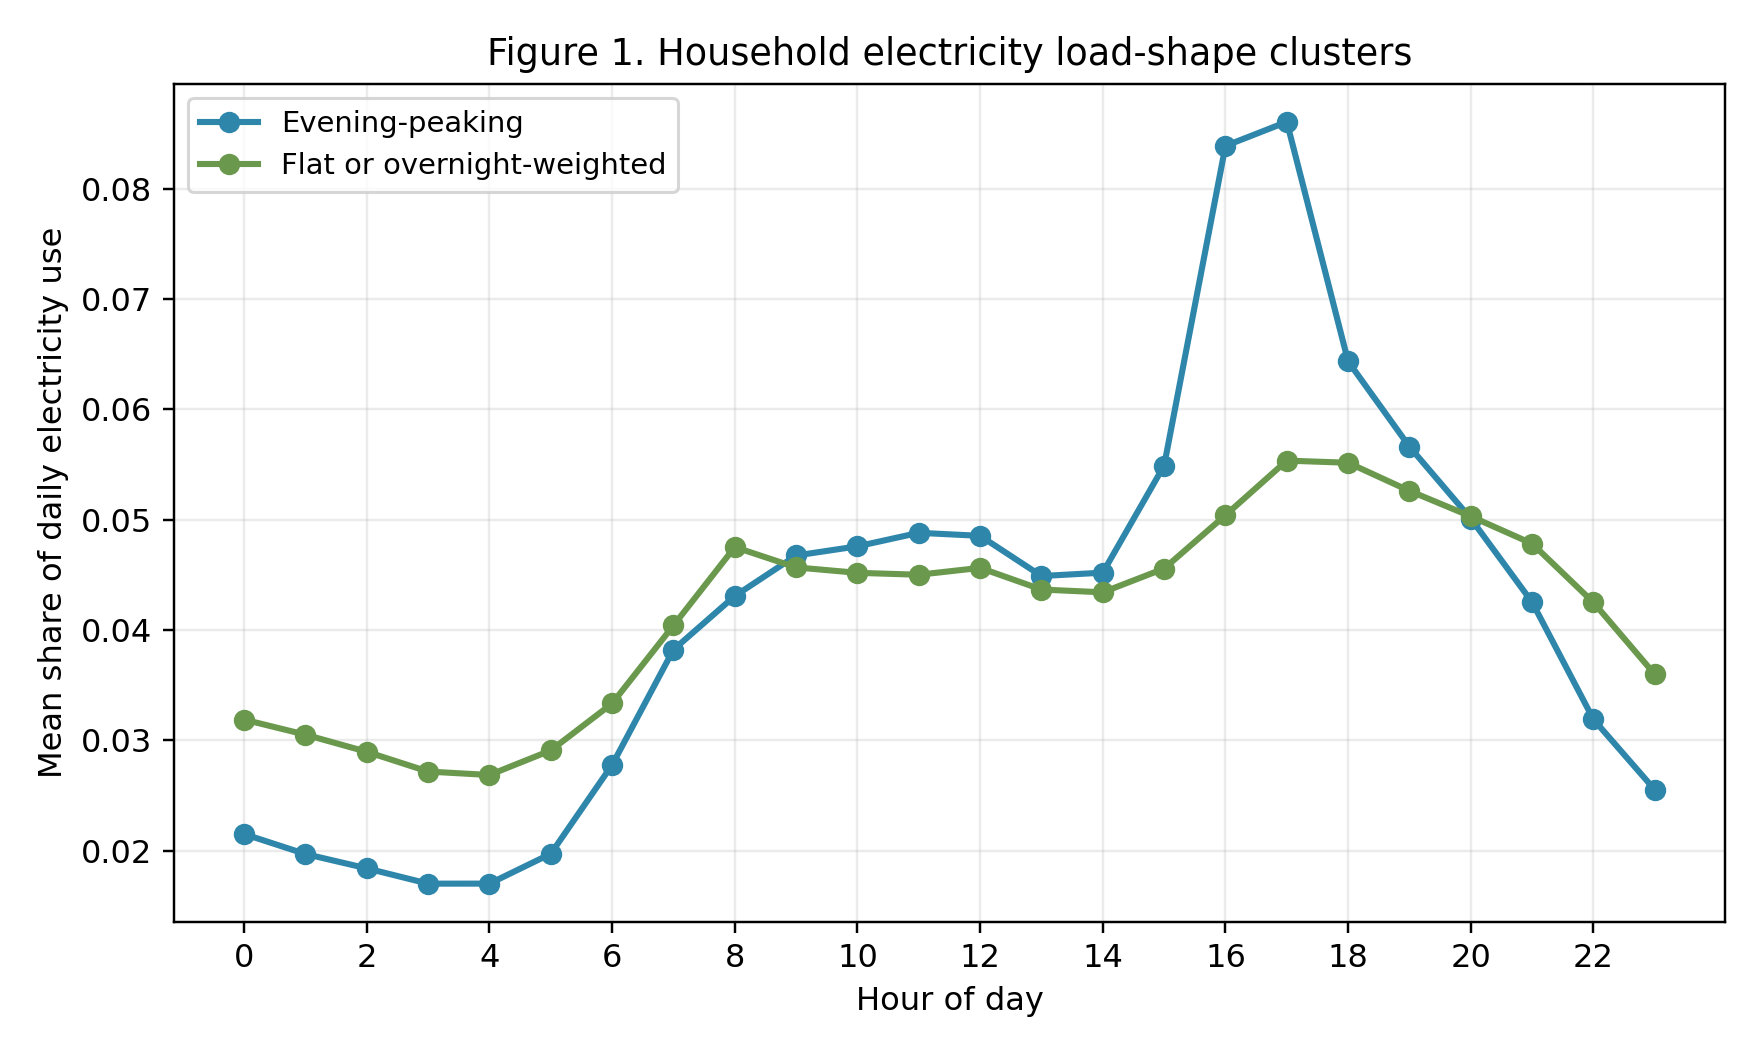

fig2_cluster_daily_kwh.png


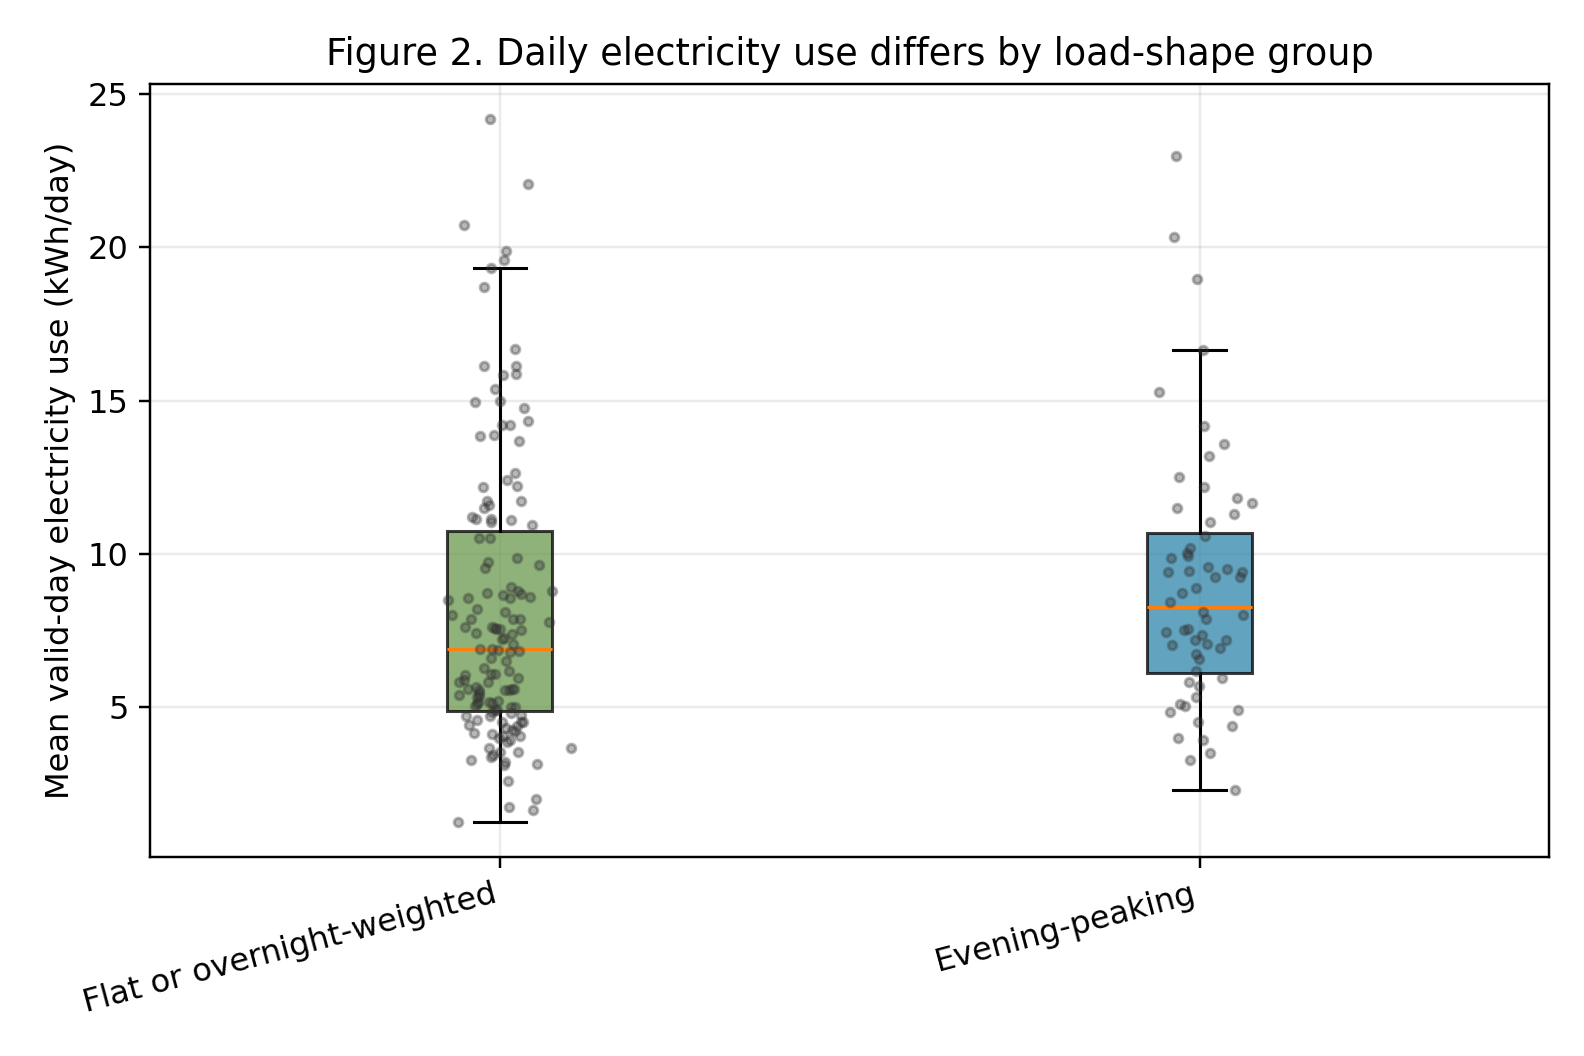

fig3_survey_cluster_heatmap.png


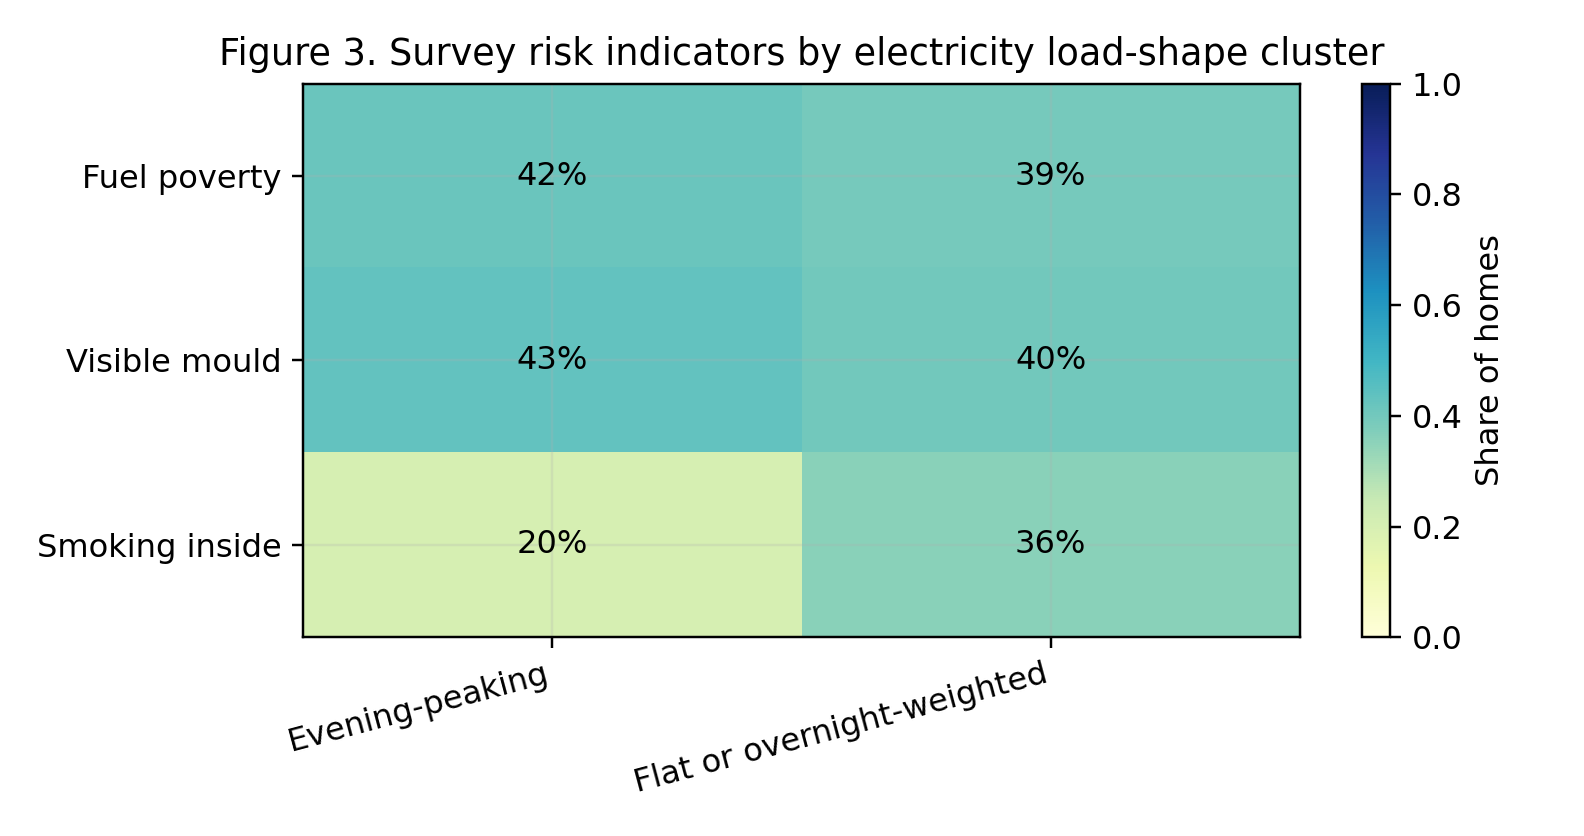

fig4_damp_cold_by_mould.png


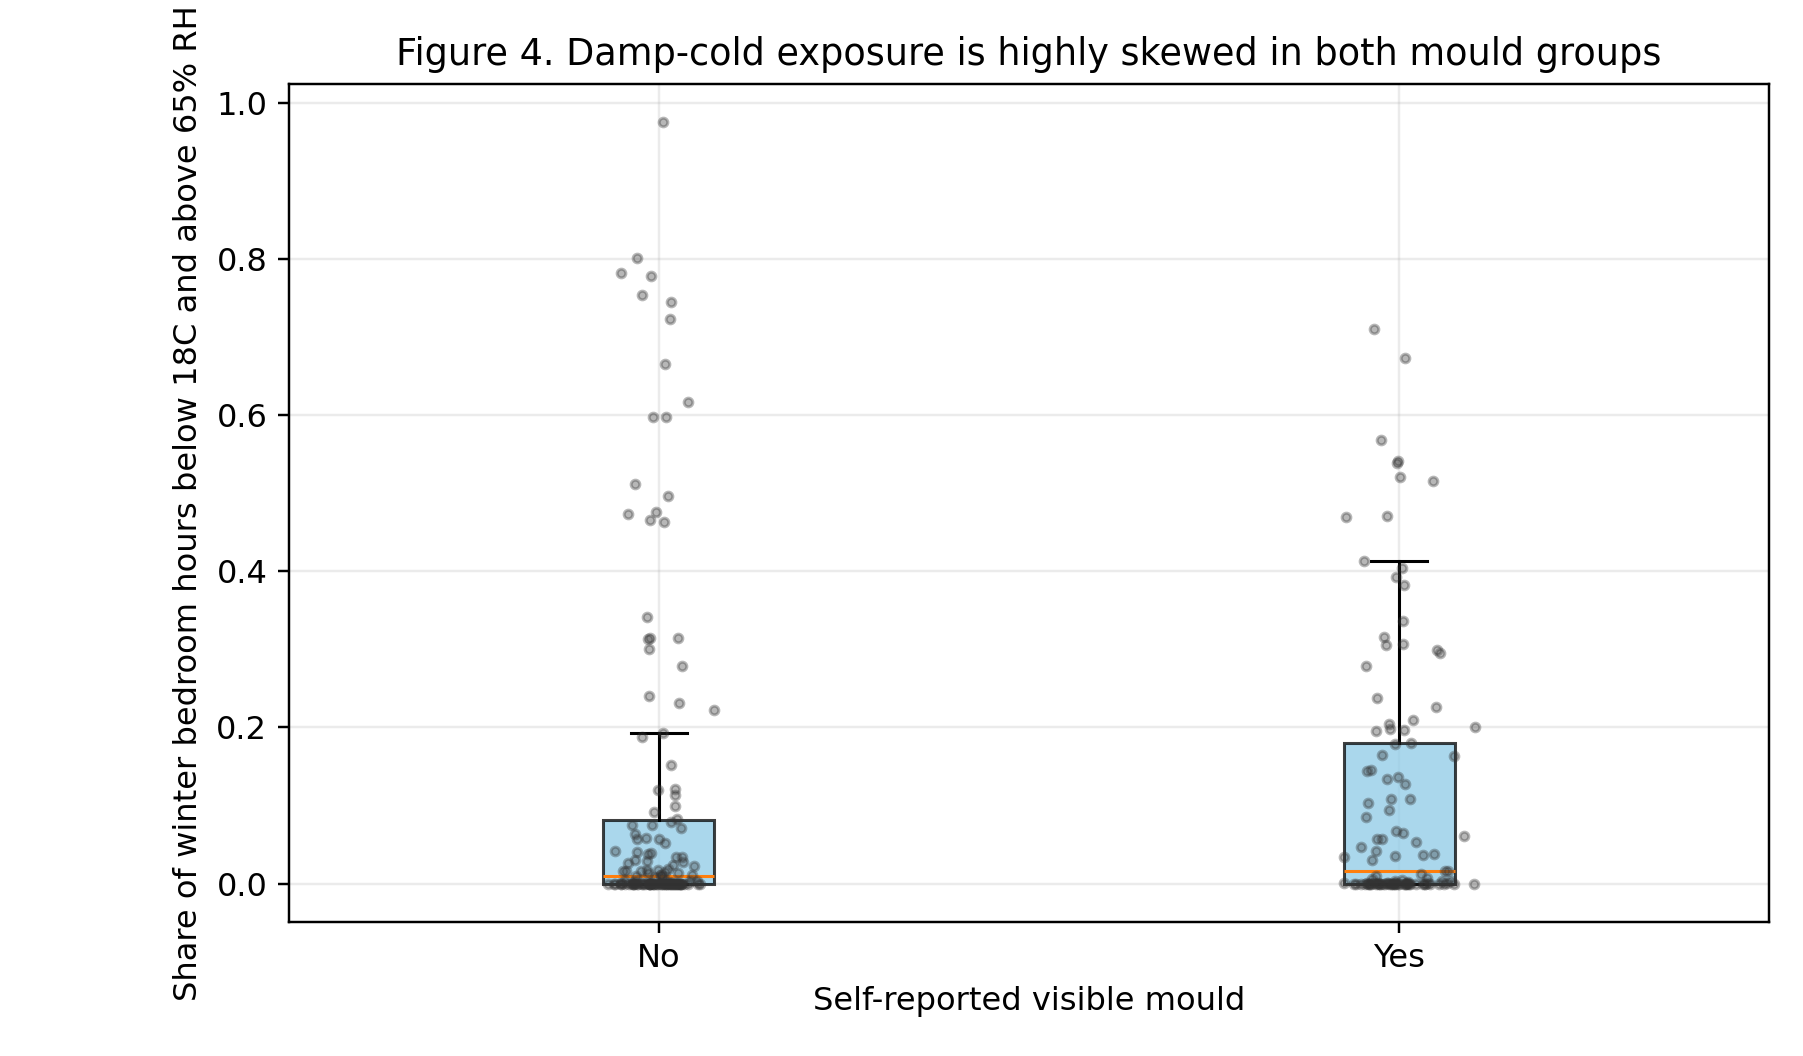

fig5_heat_pump_scenario.png


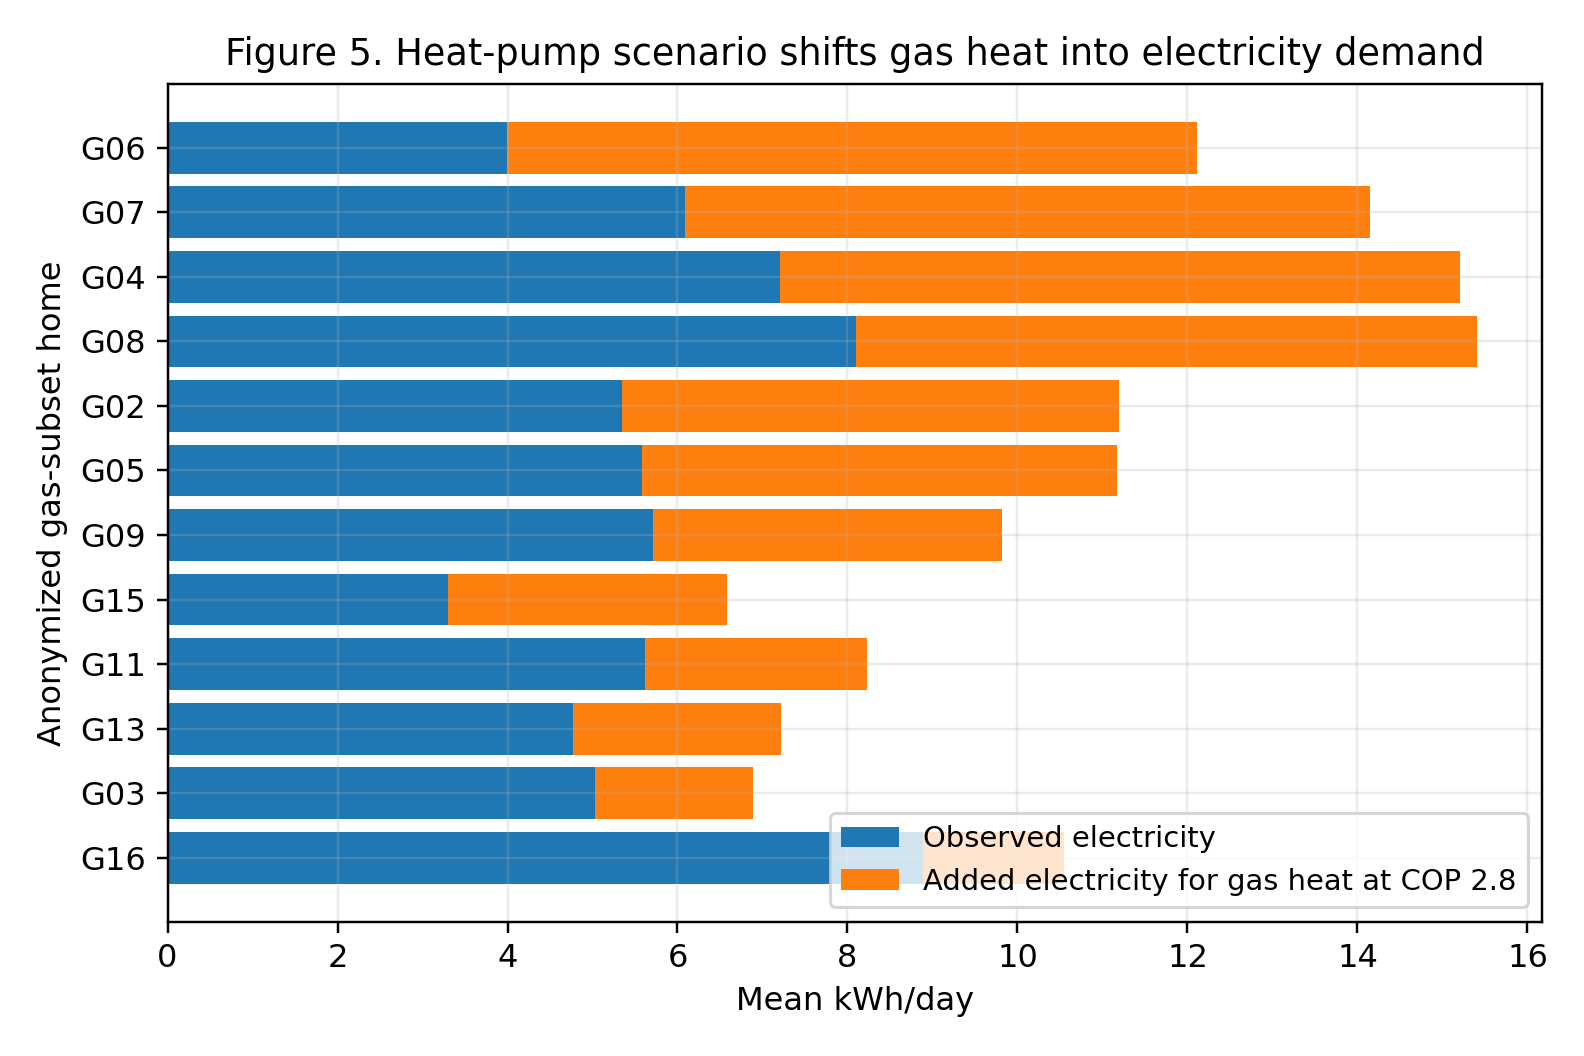

In [12]:
from IPython.display import Image, display

for fig_path in sorted(FIG.glob("fig*.png")):   # render the five Part I figures inline
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

# Part II: Report results

The cells below reproduce the six figures used in the report.
Figure map:
* R1 cohort audit (report Fig. 1)
* R2 monthly series (Fig. 2)
* R3 per-year seasonal contrasts (Fig. 3)
* R4 physics check (Fig. 4)
* R5 annual harmonic (Fig. 5)
* R6 corrected economics (Fig. 6)

## 9. Report palette and helpers

In [13]:
# Colours follow the report's validated palette (categorical slots, fixed order).
C1_BLUE, C2_AQUA, C6_RED = "#2a78d6", "#1baf7a", "#e34948"   # gas home / ASHP home / emphasis
C8_ORANGE, C4_GREEN = "#eb6834", "#008300"                    # scenario alternatives
TEXT_2 = "#52514e"                                            # secondary ink for chrome

REPORT_FIG = FIG / "report"                                   # keep report figures apart from Part I's
REPORT_FIG.mkdir(parents=True, exist_ok=True)                 # safe on reruns

def show(fig_path):
    # render a saved PNG inline; saving-then-showing keeps a file artefact in Drive
    from IPython.display import Image, display
    display(Image(filename=str(fig_path)))

## 10. Rebuild the matched pair's monthly table from raw sensors
The table is rebuilt from the raw minute-level sensor streams and then restricted to the report's core window: the two complete June-May seasonal years (24 months).
The partial May 2018 gas month and the incomplete third year are dropped so that each calendar month is balanced across the two years.

In [14]:
GAS_M3_TO_KWH_STAT = round(39.5 * 1.02264 / 3.6, 3)   # statutory conversion = 11.221, not the sheet's 11.0

def monthly_from_raw(folder, uprn):
    files = sorted(folder.glob(f"ts_{uprn:04d}_sid*.csv"))        # locate this home's sensor file by UPRN
    if not files:
        raise FileNotFoundError(f"no sensor file for UPRN {uprn} in {folder}")  # fail loudly, not silently
    raw = read_energy_file(files[0])                              # reuse Part I's cleaned reader
    s = raw.set_index("datetime")["value"]                        # increments indexed by timestamp
    s = s[s >= 0]                                                 # negative increments are sensor faults
    return s.resample("MS").sum()                                 # calendar-month totals

gas111_m3 = monthly_from_raw(GAS_DIR, 111)                        # gas home: gas meter (m3)
elec111 = monthly_from_raw(ELECTRICITY_DIR, 111)                 # gas home: electricity (kWh)
elec15 = monthly_from_raw(ELECTRICITY_DIR, 15)                   # ASHP home: electricity (kWh, its only fuel)

pair = pd.DataFrame({"gas_m3": gas111_m3, "gash_elec_kwh": elec111,
                     "ashp_elec_kwh": elec15}).dropna()          # align the three series on complete months
pair["gas_kwh"] = pair["gas_m3"] * GAS_M3_TO_KWH_STAT            # m3 -> kWh at the statutory factor
pair["gash_total_kwh"] = pair["gas_kwh"] + pair["gash_elec_kwh"] # all energy entering the gas home

# The report's core window: the two complete June-May seasonal years (24 months).
pair = pair.loc["2018-06-01":"2020-05-01"].copy()
pair["sy"] = np.where(pair.index.month >= 6, pair.index.year, pair.index.year - 1)   # season-year label
assert len(pair) == 24 and sorted(pair["sy"].unique()) == [2018, 2019]              # balanced two years

SUMMER, WINTER = (6, 7, 8), (12, 1, 2)                           # JJA vs DJF, as in the report
print(f"{len(pair)} complete months, {pair.index.min():%b %Y} to {pair.index.max():%b %Y}; "
      f"season years {sorted(pair['sy'].unique())}")
pair.round(1).head(12)                                           # first year, for inspection


24 complete months, Jun 2018 to May 2020; season years [np.int32(2018), np.int32(2019)]


,gas_m3,gash_elec_kwh,ashp_elec_kwh,gas_kwh,gash_total_kwh,sy
datetime,,,,,,
2018-06-01,24.4,244.7,222.1,273.5,518.2,2018
2018-07-01,7.9,227.4,215.7,88.9,316.3,2018
2018-08-01,15.8,231.4,269.3,177.5,408.9,2018
2018-09-01,30.4,215.8,235.8,341.2,557.0,2018
2018-10-01,73.4,261.9,287.6,823.7,1085.6,2018
2018-11-01,121.1,258.0,234.8,1359.1,1617.1,2018
2018-12-01,121.8,294.5,235.5,1366.7,1661.2,2018
2019-01-01,138.8,280.6,252.7,1557.6,1838.2,2018
2019-02-01,118.4,239.3,218.4,1328.2,1567.5,2018


## 11. Figure R1: cohort audit
Executed-run result: 259 covariate-compatible gas–ASHP pairings across the full 277-home survey (241 gas-labelled vs 12 ASHP), with 111–15 present. The report's 28-home extract had 11; the full-survey audit shows how much unexamined comparison space the previous attempt left.

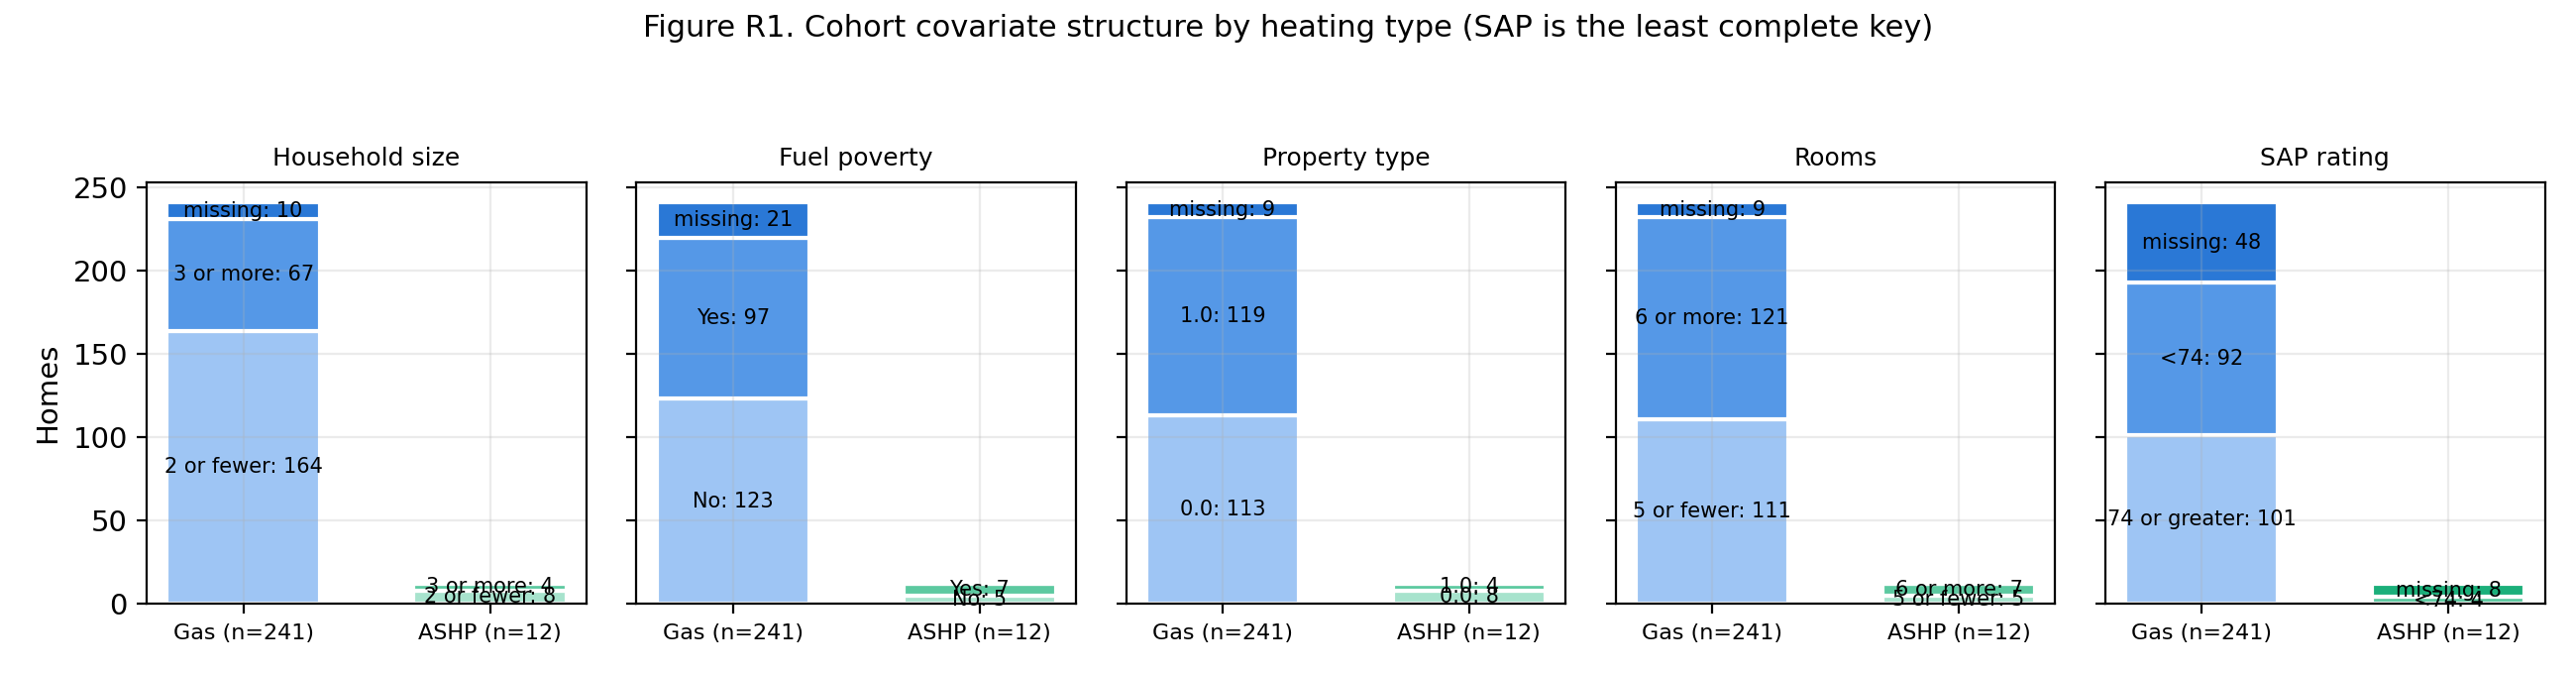

259 covariate-compatible gas-ASHP pairings on the four usable keys; UPRN 111-15 present: True
On the report's 28-home extract this count is 11, so the costed pair is one of eleven compatible pairings rather than a unique match.


In [15]:
cohort = survey.copy()                                            # audit runs on the survey table
cohort["group"] = np.where(
    cohort["Heating"].astype(str).str.contains("Heat Pump", case=False, na=False),
    "ASHP",                                                       # anything labelled heat pump
    np.where(cohort["Heating"].astype(str).str.contains("Gas", case=False, na=False),
             "Gas", "Other"),                                     # anything labelled gas; rest excluded
)
cohort = cohort[cohort["group"].isin(["Gas", "ASHP"])]           # keep the two comparison groups

covs = [("HouseholdSize", "Household size"), ("FuelPovertyIndicated", "Fuel poverty"),
        ("propType0F", "Property type"), ("NumberOfRooms", "Rooms"),
        ("SAP_Score", "SAP rating")]                             # the recorded covariates (SAP least complete)
fig, axes = plt.subplots(1, len(covs), figsize=(13, 3.4), sharey=True)
shades = {"Gas": ["#9ec5f4", "#5598e7", "#2a78d6", "#184f95"],   # ordered tints per group
          "ASHP": ["#a7e3cd", "#5cc9a0", "#1baf7a", "#0e7a54"]}
for ax, (col, label) in zip(axes, covs):
    tab = (cohort.assign(v=cohort[col].fillna("missing").astype(str))   # make missingness visible
           .groupby(["group", "v"]).size().unstack("v")
           .reindex(["Gas", "ASHP"]).fillna(0))                  # counts per category per group
    bottoms = [0, 0]
    for j, cat in enumerate(sorted(tab.columns)):
        for i, g in enumerate(("Gas", "ASHP")):
            v = tab.loc[g, cat]
            ax.bar(i, v, bottom=bottoms[i], width=0.62,
                   color=shades[g][j % 4], edgecolor="white", linewidth=1.5)
            if v > 0:
                ax.annotate(f"{cat}: {int(v)}", (i, bottoms[i] + v / 2),
                            ha="center", va="center", fontsize=7.5)
            bottoms[i] += v
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Gas (n={int(tab.loc['Gas'].sum())})",
                        f"ASHP (n={int(tab.loc['ASHP'].sum())})"], fontsize=8)
    ax.set_title(label, fontsize=9)
axes[0].set_ylabel("Homes")
fig.suptitle("Figure R1. Cohort covariate structure by heating type "
             "(SAP is the least complete key)", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(REPORT_FIG / "figR1_cohort.png", dpi=200)           # persist to Drive
plt.close(fig)
show(REPORT_FIG / "figR1_cohort.png")                           # and render inline

# Design fact: how many gas/ASHP pairs agree on the four usable covariates?
keys = ["HouseholdSize", "FuelPovertyIndicated", "propType0F", "NumberOfRooms"]   # SAP too incomplete to use
pairs = cohort[cohort["group"] == "Gas"].merge(
    cohort[cohort["group"] == "ASHP"], on=keys, suffixes=("_gas", "_ashp"))       # cross-join on agreement
present = ((pairs["UPRN_gas"] == 111) & (pairs["UPRN_ashp"] == 15)).any()
print(f"{len(pairs)} covariate-compatible gas-ASHP pairings on the four usable keys; "
      f"UPRN 111-15 present: {present}")
print("On the report's 28-home extract this count is 11, so the costed pair is one of "
      "eleven compatible pairings rather than a unique match.")

## 12. Figures R2 and R3: monthly series and per-year seasonal contrasts

*   R2 plots the three series across the two complete years.
*   R3 replaces the old month-of-year signals with the report's per-year winter-minus-summer contrasts, which show both the size and the year-to-year stability of each contrast.
*   Report values (kWh per month): the gas home's total-energy contrast is about 1,289 (2018-19) and 822 (2019-20); its electricity alone rises 45 and 25; the ASHP home's electricity rises only 8 and 21. The electrically heated home responds to winter no more than the gas home's own appliances do.

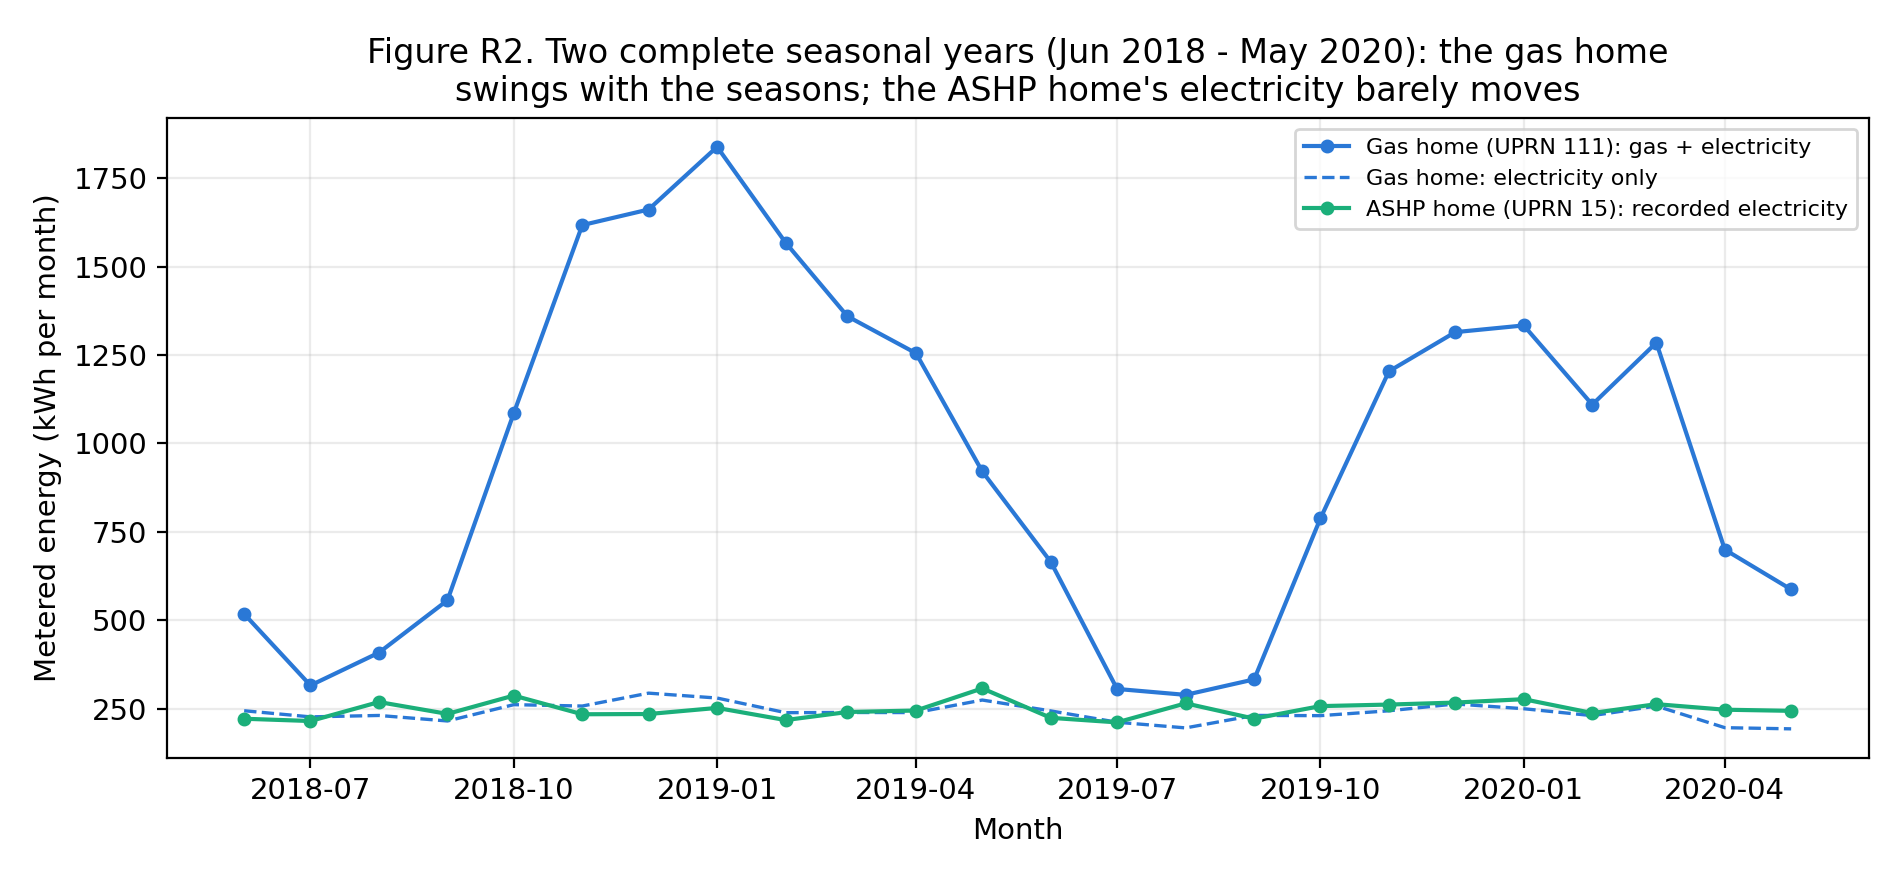

winter-minus-summer contrasts (kWh/month):
  gash_total_kwh_2018: 1274.5
  gash_total_kwh_2019: 832.3
  gash_elec_kwh_2018: 37.0
  gash_elec_kwh_2019: 30.8
  ashp_elec_kwh_2018: -0.2
  ashp_elec_kwh_2019: 27.1


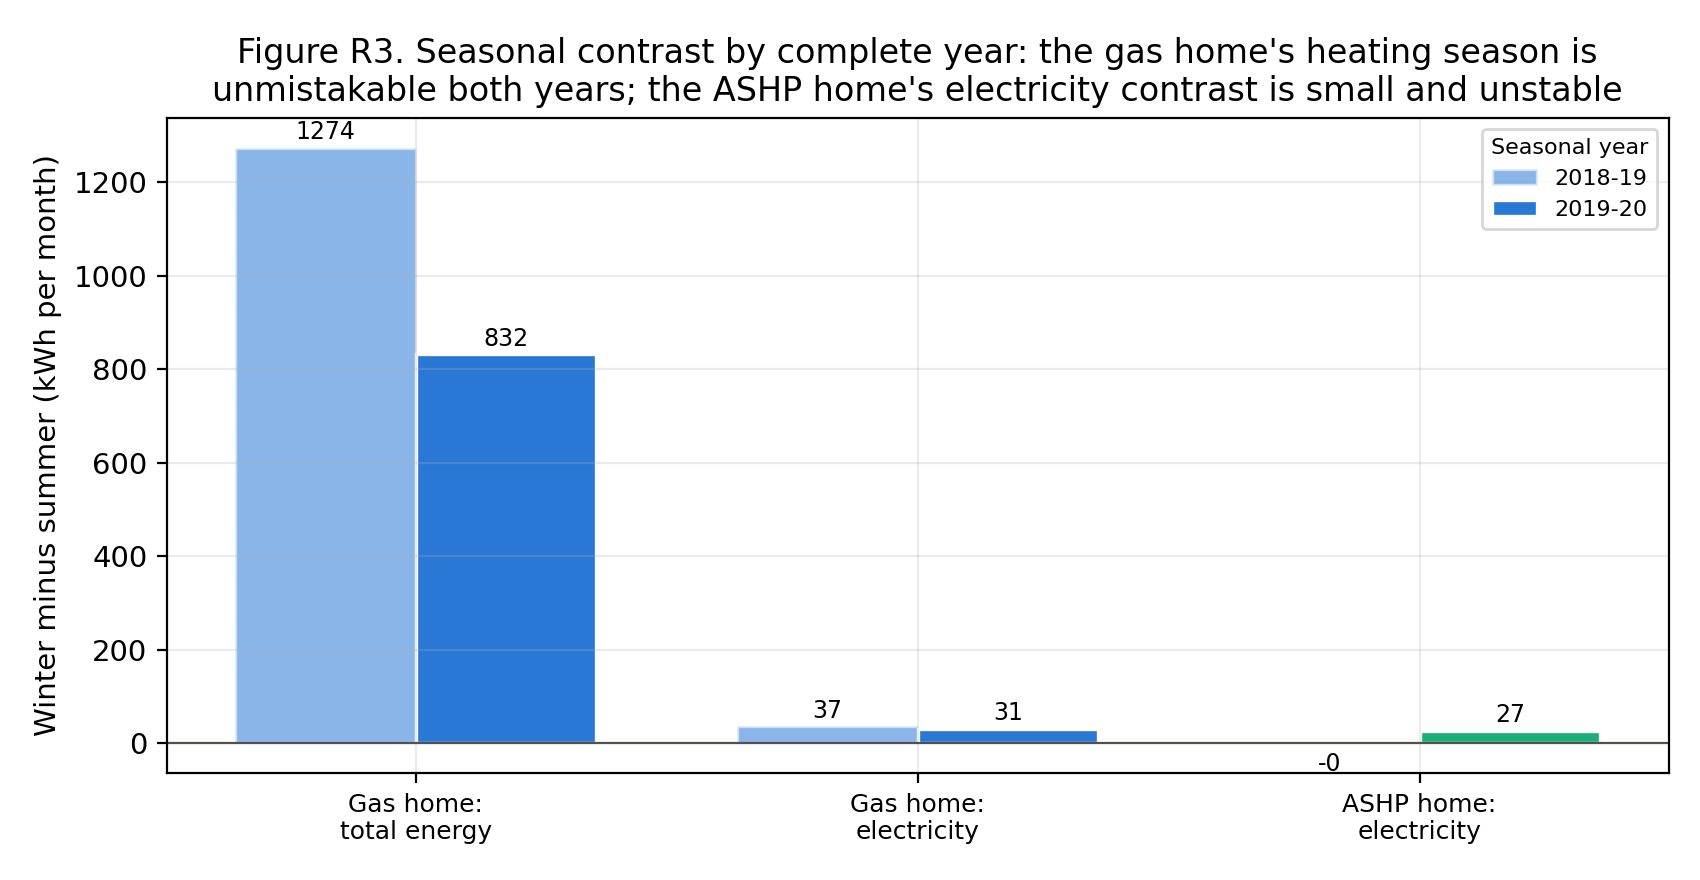

In [16]:
# Figure R2: the monthly series across the two complete seasonal years (report Fig. 2) ---
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(pair.index, pair["gash_total_kwh"], color=C1_BLUE, marker="o", markersize=4,
        label="Gas home (UPRN 111): gas + electricity")
ax.plot(pair.index, pair["gash_elec_kwh"], color=C1_BLUE, linewidth=1.2, linestyle="--",
        label="Gas home: electricity only")
ax.plot(pair.index, pair["ashp_elec_kwh"], color=C2_AQUA, marker="o", markersize=4,
        label="ASHP home (UPRN 15): recorded electricity")
ax.set_ylabel("Metered energy (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure R2. Two complete seasonal years (Jun 2018 - May 2020): the gas home\n"
             "swings with the seasons; the ASHP home's electricity barely moves")
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(REPORT_FIG / "figR2_monthly_series.png", dpi=200)
plt.close(fig); show(REPORT_FIG / "figR2_monthly_series.png")

# Figure R3: per-year winter-minus-summer contrasts (report Fig. 3) ---
SERIES = [("gash_total_kwh", "Gas home:\ntotal energy", C1_BLUE),
          ("gash_elec_kwh", "Gas home:\nelectricity", C1_BLUE),
          ("ashp_elec_kwh", "ASHP home:\nelectricity", C2_AQUA)]
contrasts = {}
for col, _, _ in SERIES:
    for sy, g in pair.groupby("sy"):
        su = g.index.month.isin(SUMMER); wi = g.index.month.isin(WINTER)
        contrasts[f"{col}_{sy}"] = round(float(g.loc[wi, col].mean() - g.loc[su, col].mean()), 1)
print("winter-minus-summer contrasts (kWh/month):")
for k, v in contrasts.items():
    print(f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(SERIES)); w = 0.36
for k, (sy, tint) in enumerate([(2018, 0.55), (2019, 1.0)]):
    vals = [contrasts[f"{col}_{sy}"] for col, _, _ in SERIES]
    cols = [C1_BLUE, C1_BLUE, C2_AQUA]
    ax.bar(x + (k - 0.5) * w, vals, w, color=cols, alpha=tint,
           edgecolor="white", linewidth=1.2, label=f"{sy}-{str(sy + 1)[2:]}")
    for xi, v in zip(x + (k - 0.5) * w, vals):
        ax.annotate(f"{v:.0f}", (xi, v), xytext=(0, 3 if v >= 0 else -10),
                    textcoords="offset points", ha="center", fontsize=8.5)
ax.axhline(0, color=TEXT_2, linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([lab for _, lab, _ in SERIES], fontsize=9)
ax.set_ylabel("Winter minus summer (kWh per month)")
ax.set_title("Figure R3. Seasonal contrast by complete year: the gas home's heating season is\n"
             "unmistakable both years; the ASHP home's electricity contrast is small and unstable")
ax.legend(title="Seasonal year", fontsize=8, title_fontsize=8)
fig.tight_layout()
fig.savefig(REPORT_FIG / "figR3_signatures.png", dpi=200)
plt.close(fig); show(REPORT_FIG / "figR3_signatures.png")

## 13. Figure R4: the physics consistency check (conditional on matched heat demand)
Each complete year gets its own summer baseline, so one year's baseline cannot leak into the other. If the ASHP home needed the same space-heating heat as its gas twin, a field-typical pump at SPF 2.9 would lift its winter electricity far above the small rise recorded. Report values: across the 18 core heating months the implied heat-to-uplift ratio has a median of 30.6 and a minimum of 13.7, three months show non-positive uplift, and at SPF 2.9 the recorded uplift covers only 6.9% of the matched heat need. The ratio is a conditional diagnostic of the combined assumptions (matched demand, correct metering, correct processing), not a measured COP.

core heating months 18, non-positive uplift months 4
implied heat-to-uplift ratio: median 22.1, min 5.5 (field COPs 2.6-3.3)
at SPF 2.9 the recorded uplift covers 9.0% of the matched heat need


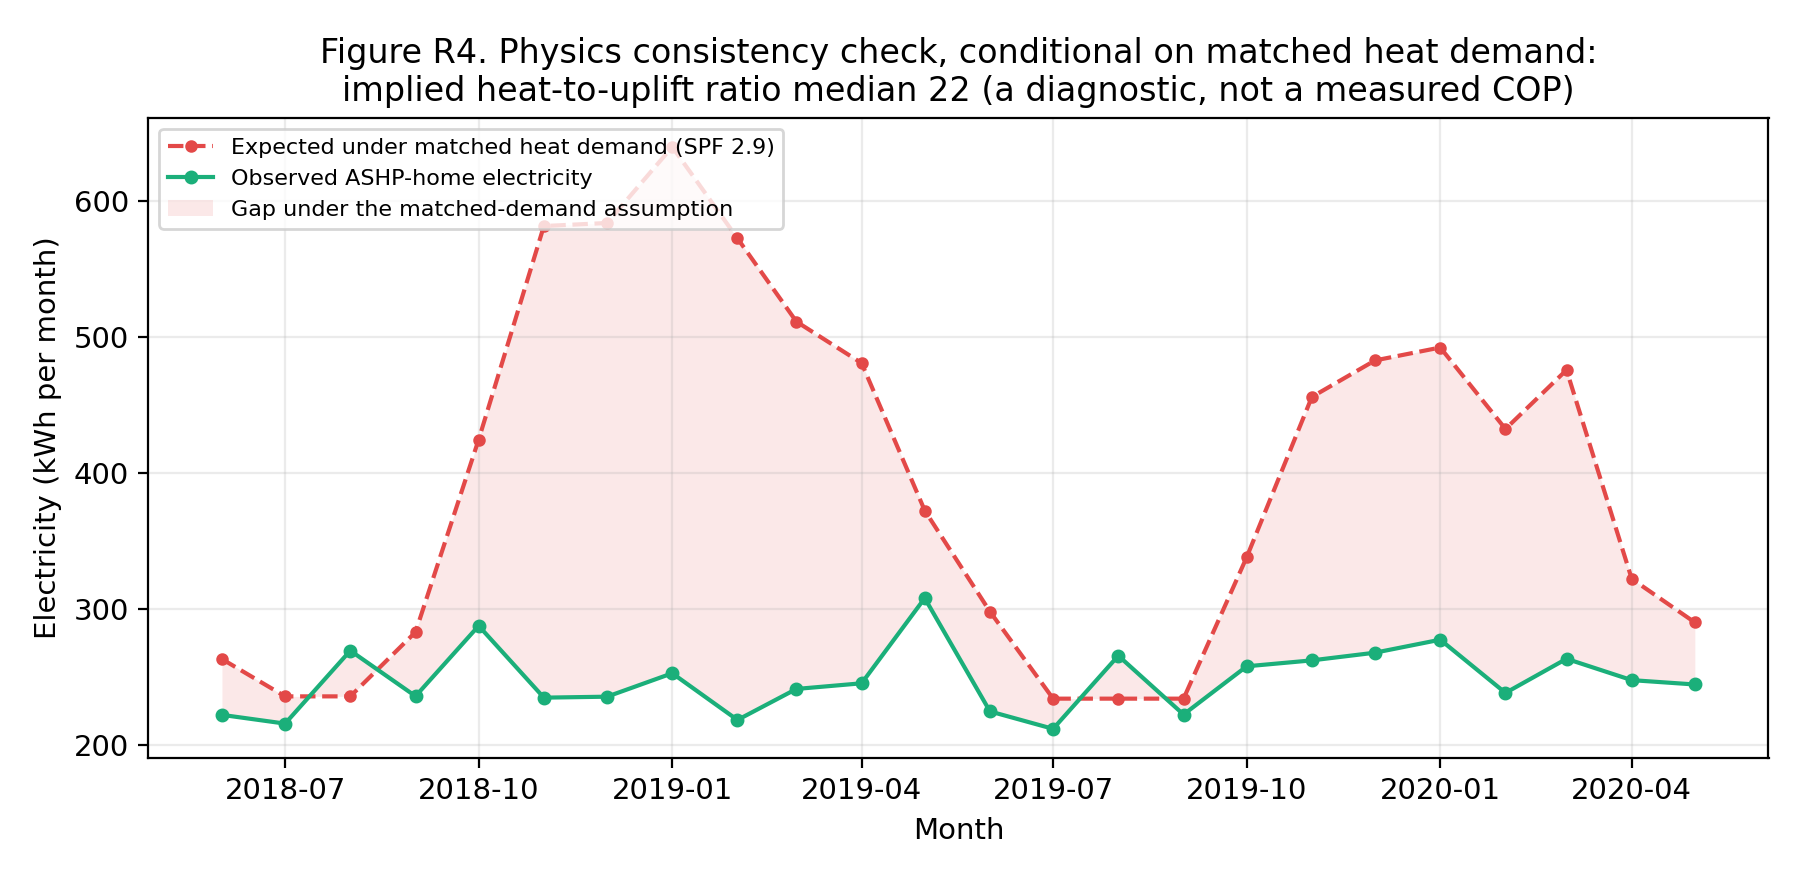

In [17]:
BOILER_EFF, FIELD_COP = 0.85, 2.9                                # in-situ boiler efficiency; field SPF

# Per-year physics check: each complete year gets its own summer baseline (report Step 4).
parts = []
for sy, g in pair.groupby("sy"):
    su = g.index.month.isin(SUMMER)
    gas_base = g.loc[su, "gas_kwh"].mean()                       # summer gas = cooking + hot water only
    ashp_base = g.loc[su, "ashp_elec_kwh"].mean()               # ASHP home's appliance baseline
    p = pd.DataFrame(index=g.index)
    p["heat"] = (g["gas_kwh"] - gas_base).clip(lower=0) * BOILER_EFF     # useful space-heating heat
    p["uplift"] = (g["ashp_elec_kwh"] - ashp_base).clip(lower=0)         # winter rise above baseline
    p["expected"] = ashp_base + p["heat"] / FIELD_COP                    # what a real pump would draw
    p["observed"] = g["ashp_elec_kwh"]
    parts.append(p)
phys = pd.concat(parts)

core = phys["heat"] > 100                                        # real heating months only (avoids 0/0)
nonpos = int((core & (phys["uplift"] <= 0)).sum())              # months with heat but no uplift
ratio = (phys.loc[core, "heat"] /
         phys.loc[core, "uplift"].where(phys.loc[core, "uplift"] > 0)).dropna()   # implied heat-to-uplift ratio
coverage = 100 * FIELD_COP * phys.loc[core, "uplift"].sum() / phys.loc[core, "heat"].sum()
print(f"core heating months {int(core.sum())}, non-positive uplift months {nonpos}")
print(f"implied heat-to-uplift ratio: median {ratio.median():.1f}, min {ratio.min():.1f} "
      f"(field COPs 2.6-3.3)")
print(f"at SPF {FIELD_COP} the recorded uplift covers {coverage:.1f}% of the matched heat need")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(phys.index, phys["expected"], color=C6_RED, linestyle="--", marker="o", markersize=3.5,
        label=f"Expected under matched heat demand (SPF {FIELD_COP})")
ax.plot(phys.index, phys["observed"], color=C2_AQUA, marker="o", markersize=4,
        label="Observed ASHP-home electricity")
ax.fill_between(phys.index, phys["observed"], phys["expected"], color=C6_RED, alpha=0.12,
                linewidth=0, label="Gap under the matched-demand assumption")
ax.set_ylabel("Electricity (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure R4. Physics consistency check, conditional on matched heat demand:\n"
             f"implied heat-to-uplift ratio median {ratio.median():.0f} (a diagnostic, not a measured COP)")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(REPORT_FIG / "figR4_physics.png", dpi=200)
plt.close(fig); show(REPORT_FIG / "figR4_physics.png")

## 14. Figure R5: optional harmonic model of the heating season
The earlier month-shuffle permutation test is dropped. With only two complete seasonal years the monthly values are serially ordered around a fixed annual cycle, so month labels are not exchangeable and a shuffled-month p-value would overstate the inference. A transparent four-parameter annual harmonic (intercept, linear trend and one Fourier pair) is fitted to the gas home's monthly gas demand instead. Report values: R-squared 0.91, RMSE about 138 kWh per month. The gas heating season is that regular, which is why the flat ASHP meter is hard to reconcile with normal operation.

annual harmonic: 4 parameters, R^2 = 0.91, RMSE = 139.6 kWh/month


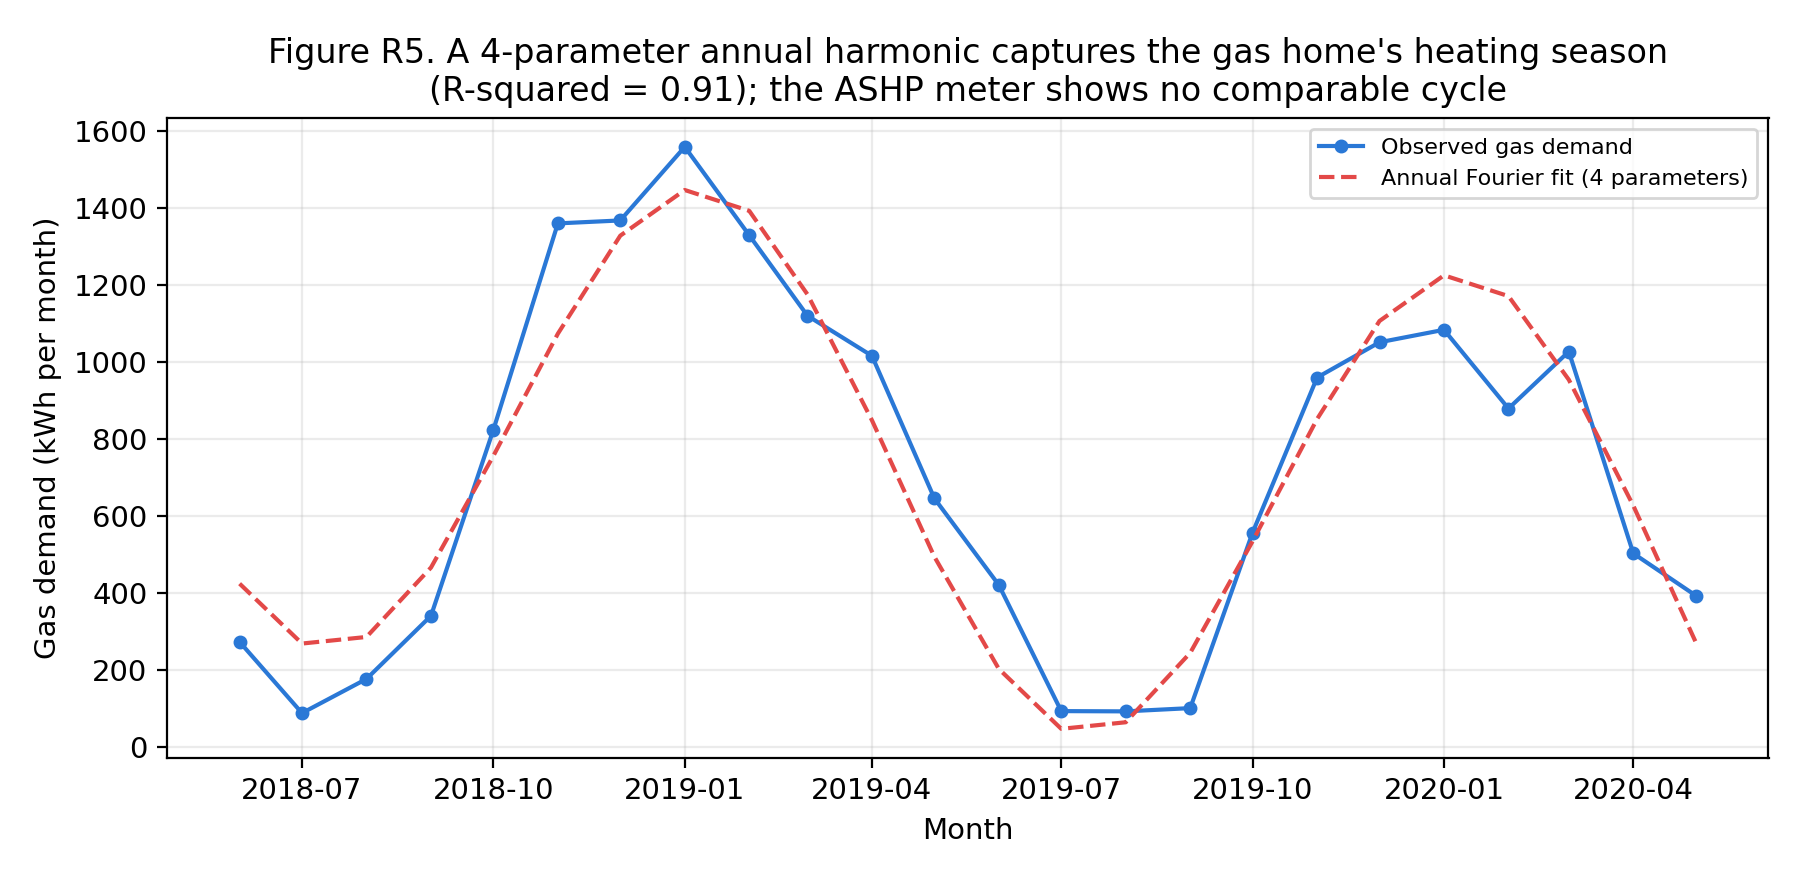

In [18]:
# Optional harmonic model of the gas home's heating season (report Step 5 / Fig. 5).
gas = pair["gas_kwh"].copy()

def fourier_design(index):
    t = np.arange(len(index), dtype=float)
    return np.column_stack([np.ones(len(index)), t,
                            np.sin(2 * np.pi * t / 12), np.cos(2 * np.pi * t / 12)])

X = fourier_design(gas.index)
beta, *_ = np.linalg.lstsq(X, gas.to_numpy(), rcond=None)        # ordinary least squares on 4 columns
fit = pd.Series(X @ beta, index=gas.index).clip(lower=0)         # fitted annual cycle
resid = gas - fit
r2 = 1 - float((resid ** 2).sum()) / float(((gas - gas.mean()) ** 2).sum())
rmse = float(np.sqrt((resid ** 2).mean()))
print(f"annual harmonic: {X.shape[1]} parameters, R^2 = {r2:.2f}, RMSE = {rmse:.1f} kWh/month")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(gas.index, gas.to_numpy(), color=C1_BLUE, marker="o", markersize=4,
        label="Observed gas demand")
ax.plot(fit.index, fit.to_numpy(), color=C6_RED, linestyle="--",
        label="Annual Fourier fit (4 parameters)")
ax.set_ylabel("Gas demand (kWh per month)"); ax.set_xlabel("Month")
ax.set_title("Figure R5. A 4-parameter annual harmonic captures the gas home's heating season\n"
             f"(R-squared = {r2:.2f}); the ASHP meter shows no comparable cycle")
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(REPORT_FIG / "figR5_harmonic.png", dpi=200)
plt.close(fig); show(REPORT_FIG / "figR5_harmonic.png")

15. Figure R6: corrected economics

The source spreadsheet priced gas by cubic metres instead of kWh (an ~11x understatement, corrected here: about GBP 66 by volume against GBP 738 by energy on the first complete year).

Bills are repriced at the historical Jan-Mar 2024 Ofgem cap, and the defensible comparison is the within-home counterfactual: the gas home's own heat re-delivered by an ASHP at SPF 2.9 through its own meter.
Report values:
*   gas home GBP 1,851
*   within-home switch GBP 1,840 (saving about GBP 12)
*   sensitivity from GBP -179 to GBP +236 across boiler efficiency and SPF
*   break-even ratio 3.41 against the cap's 3.86
*   carbon from 2.41 to 1.19 tCO2e.

sheet-style gas cost (priced by m3): GBP 67  vs correct (by kWh): GBP 749
gas home bill GBP 1913 | within-home switch GBP 1903 (saving GBP 10)
sensitivity saving range: GBP -183 to GBP 238
break-even price ratio 3.41 vs cap 3.86
carbon: gas home 2.47 t -> switch 1.24 t CO2e


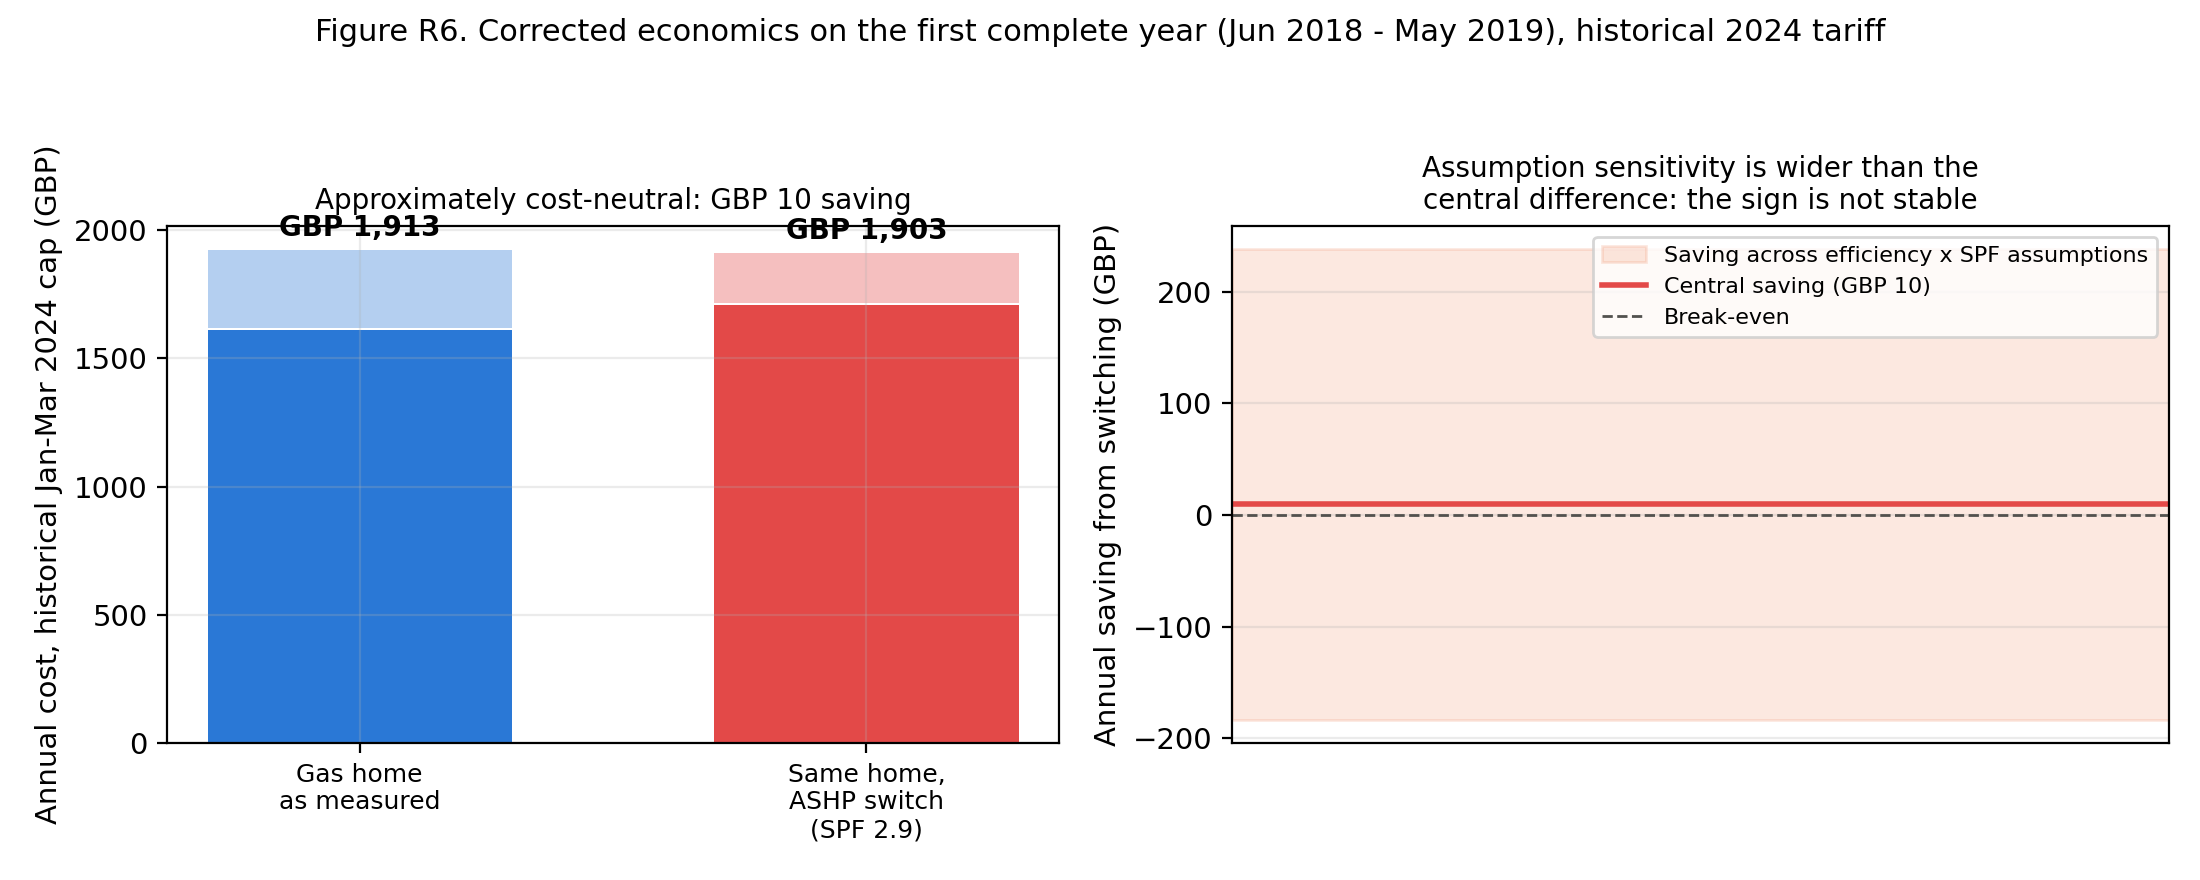

In [19]:
# Corrected economics on the first complete June-May year, historical Jan-Mar 2024 cap (report Fig. 6).
P_ELEC, P_GAS = 0.2862, 0.0742                                   # Ofgem cap unit rates (GBP/kWh)
SC_ELEC, SC_GAS = 0.5335 * 365, 0.2960 * 365                     # annualised standing charges

yr = pair[pair["sy"] == 2018]                                    # first complete June-May year
assert len(yr) == 12
gas_kwh = float(yr["gas_kwh"].sum())
gash_elec = float(yr["gash_elec_kwh"].sum())
heat = gas_kwh * BOILER_EFF                                      # useful heat the gas delivered
switch_elec = heat / FIELD_COP                                  # ASHP electricity for that heat

gash_bill = gas_kwh * P_GAS + SC_GAS + gash_elec * P_ELEC + SC_ELEC       # gas home, as measured
switch_bill = (gash_elec + switch_elec) * P_ELEC + SC_ELEC                 # same home, switched
central = gash_bill - switch_bill

# sensitivity across boiler efficiency x SPF: is the sign of the saving stable?
savings = []
for eta in (0.75, 0.85, 0.90):
    for spf in (2.5, 2.9, 3.5):
        cand = (gash_elec + gas_kwh * eta / spf) * P_ELEC + SC_ELEC
        savings.append(gash_bill - cand)
savings = np.array(savings)

print(f"sheet-style gas cost (priced by m3): GBP {float(yr['gas_m3'].sum()) * P_GAS:.0f}"
      f"  vs correct (by kWh): GBP {gas_kwh * P_GAS:.0f}")        # the 11x error, made visible
print(f"gas home bill GBP {gash_bill:.0f} | within-home switch GBP {switch_bill:.0f} "
      f"(saving GBP {central:.0f})")
print(f"sensitivity saving range: GBP {savings.min():.0f} to GBP {savings.max():.0f}")
print(f"break-even price ratio {FIELD_COP / BOILER_EFF:.2f} vs cap {P_ELEC / P_GAS:.2f}")
print(f"carbon: gas home {(gas_kwh * 0.183 + gash_elec * 0.207) / 1000:.2f} t"
      f" -> switch {(gash_elec + switch_elec) * 0.207 / 1000:.2f} t CO2e")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.05]})
labels = ["Gas home\nas measured", "Same home,\nASHP switch\n(SPF 2.9)"]
fuel = [gas_kwh * P_GAS + gash_elec * P_ELEC, (gash_elec + switch_elec) * P_ELEC]
standing = [SC_GAS + SC_ELEC, SC_ELEC]
for i, (f_, s_, c) in enumerate(zip(fuel, standing, [C1_BLUE, C6_RED])):
    ax0.bar(i, f_, width=0.6, color=c)
    ax0.bar(i, s_, bottom=f_ + 8, width=0.6, color=c, alpha=0.35)
    ax0.annotate(f"GBP {f_ + s_:,.0f}", (i, f_ + s_ + 8), ha="center",
                 xytext=(0, 5), textcoords="offset points", fontsize=10, fontweight="bold")
ax0.set_xticks([0, 1]); ax0.set_xticklabels(labels, fontsize=9)
ax0.set_ylabel("Annual cost, historical Jan-Mar 2024 cap (GBP)")
ax0.set_title(f"Approximately cost-neutral: GBP {central:.0f} saving", fontsize=10)
ax0.grid(alpha=0.25)

ax1.axhspan(savings.min(), savings.max(), color=C8_ORANGE, alpha=0.15,
            label="Saving across efficiency x SPF assumptions")
ax1.axhline(central, color=C6_RED, linewidth=2, label=f"Central saving (GBP {central:.0f})")
ax1.axhline(0, color=TEXT_2, linewidth=1, linestyle="--", label="Break-even")
ax1.set_xlim(0, 1); ax1.set_xticks([])
ax1.set_ylabel("Annual saving from switching (GBP)")
ax1.set_title("Assumption sensitivity is wider than the\ncentral difference: the sign is not stable",
              fontsize=10)
ax1.legend(loc="upper right", fontsize=8)

fig.suptitle("Figure R6. Corrected economics on the first complete year "
             "(Jun 2018 - May 2019), historical 2024 tariff", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(REPORT_FIG / "figR6_costs.png", dpi=200)
plt.close(fig); show(REPORT_FIG / "figR6_costs.png")